In [51]:
# Date range filter - just for plotting
START_DATE = '2026-01-26'  # Format: 'YYYY-MM-DD'
END_DATE = '2026-01-30'    # Format: 'YYYY-MM-DD'

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import seaborn as sns

# Define file paths for all 4 files
acc_file1 = Path('/Users/xylu/Desktop/Data/machine_local/acc/2026-01-30T17_34_39.363Z.csv')
acc_file2 = Path('/Users/xylu/Desktop/Data/machine_local/acc/2026-01-30T17_38_27.785Z.csv')
belle2_file = Path('/Users/xylu/Desktop/Data/machine_local/belle2/2026-01-30T17_30_53.825Z.csv')
vacuum_file = Path('/Users/xylu/Desktop/Data/machine_local/vacuum/2026-01-30T17_30_05.334Z.csv')

# Read all CSV files with timestamp parsing
acc_df1 = pd.read_csv(acc_file1, parse_dates=['Timestamp'])
acc_df2 = pd.read_csv(acc_file2, parse_dates=['Timestamp'])
belle2_df = pd.read_csv(belle2_file, parse_dates=['Timestamp'])
vacuum_df = pd.read_csv(vacuum_file, parse_dates=['Timestamp'])

print(f"ACC file 1 shape: {acc_df1.shape}")
print(f"ACC file 2 shape: {acc_df2.shape}")
print(f"Belle2 data shape: {belle2_df.shape}")
print(f"Vacuum data shape: {vacuum_df.shape}")
print(f"\nACC file 1 columns ({len(acc_df1.columns)}): {list(acc_df1.columns)}")
print(f"\nACC file 2 columns ({len(acc_df2.columns)}): {list(acc_df2.columns)}")
print(f"\nBelle2 columns ({len(belle2_df.columns)}): {list(belle2_df.columns)}")
print(f"\nVacuum columns ({len(vacuum_df.columns)}): {list(vacuum_df.columns)}")

# Save all numeric columns to variables for correlation analysis
acc1_numeric_cols = acc_df1.select_dtypes(include=[np.number]).columns.tolist()
acc2_numeric_cols = acc_df2.select_dtypes(include=[np.number]).columns.tolist()
belle2_numeric_cols = belle2_df.select_dtypes(include=[np.number]).columns.tolist()
vacuum_numeric_cols = vacuum_df.select_dtypes(include=[np.number]).columns.tolist()

# Combine all data - merge on timestamp with outer join to preserve all data
# First add source column to track origin
acc_df1['source'] = 'ACC1'
acc_df2['source'] = 'ACC2'
belle2_df['source'] = 'Belle2'
vacuum_df['source'] = 'Vacuum'

# Concatenate all dataframes
all_data_list = [acc_df1, acc_df2, belle2_df, vacuum_df]
all_data = pd.concat(all_data_list, axis=0, ignore_index=True, sort=False)

# Save all unique numeric columns (excluding source)
all_numeric_columns = list(set(acc1_numeric_cols + acc2_numeric_cols + belle2_numeric_cols + vacuum_numeric_cols))

# Get min/max dates from all data
all_timestamps = pd.concat([
    acc_df1['Timestamp'],
    acc_df2['Timestamp'],
    belle2_df['Timestamp'],
    vacuum_df['Timestamp']
])

print(f"\n--- Summary ---")
print(f"Total rows combined: {len(all_data)}")
print(f"Total unique numeric columns: {len(all_numeric_columns)}")
print(f"Available data range: {all_timestamps.min()} to {all_timestamps.max()}")
print(f"\nAll numeric columns available for correlation analysis:")
for i, col in enumerate(sorted(all_numeric_columns), 1):
    print(f"  {i:2d}. {col}")

ACC file 1 shape: (6840, 20)
ACC file 2 shape: (4240, 9)
Belle2 data shape: (11101, 10)
Vacuum data shape: (8599, 24)

ACC file 1 columns (20): ['Timestamp', 'B2_nsm:get:ECL_LUM_MON:lum_acc_20', 'CG_OPR:SpecificLuminosity', 'BMLDCCT:CURRENT', 'CGLOPT:IP:BETA_X', 'CGLOPT:IP:BETA_Y', 'CG_OPT:CAP:SIGMAY', 'BTpBPM:QMD11P_K_1:NC_1Hz:C', 'CGLINJ:EFFICIENCY', 'LIiEV:BEAM_REP:READ:KBP', 'CGLINJ:KICKER:HEIGHT_R', 'CGLINJ:KICKER:JUMP_R', 'CGLINJ:SEPTUM:POS_R', 'CGLINJ:SEPTUM:ANG_R', 'LIiRF:MOPS:SET_PHASE:LER', 'CGLINJ:INJECTION:YPOS', 'CGLINJ:INJECTION:YANG', 'BMLD07:INJ:X', 'BMLD07:INJ:Y', 'BMLD07:INJ:Q']

ACC file 2 columns (9): ['Timestamp', 'VALCLM:D06CV1TOP:RQ:SET_POS', 'VALCLM:D06CV1TOP:ST:POS', 'VALCLM:D06CV1BTM:RQ:SET_POS', 'VALCLM:D06CV1BTM:ST:POS', 'BML:MQTAFOP1:POS.PXP', 'BML:MQTAFOP1:POS.PYP', 'BML:MQT3FOP1:POS.PXP', 'BML:MQT3FOP1:POS.PYP']

Belle2 columns (10): ['Timestamp', 'B2_VXD:Rad:Res:BPAtDCU3:A1:DoseRate', 'B2_VXD:Rad:QCS_FW_225:DoseRate', 'B2_VXD:Rad:QCS_FW_135:DoseRate', 'B

In [53]:
# Save each individual column as a separate variable for easy access
# Create a dictionary to store all columns with their data
columns_dict = {}

# Function to create safe variable names from column names
def safe_var_name(col_name, source):
    # Replace special characters with underscores
    safe_name = col_name.replace(':', '_').replace('.', '_').replace('-', '_')
    safe_name = safe_name.replace('(', '').replace(')', '').replace(' ', '_')
    return f"{source}_{safe_name}"

# Store ACC file 1 columns (use 'acc' prefix)
for col in acc1_numeric_cols:
    var_name = safe_var_name(col, 'acc')
    columns_dict[var_name] = acc_df1[col].values
    # Also create the variable in the global namespace
    globals()[var_name] = acc_df1[col].values

# Store ACC file 2 columns (use 'acc' prefix)
for col in acc2_numeric_cols:
    var_name = safe_var_name(col, 'acc')
    columns_dict[var_name] = acc_df2[col].values
    globals()[var_name] = acc_df2[col].values

# Store Belle2 columns
for col in belle2_numeric_cols:
    var_name = safe_var_name(col, 'belle2')
    columns_dict[var_name] = belle2_df[col].values
    globals()[var_name] = belle2_df[col].values

# Store Vacuum columns
for col in vacuum_numeric_cols:
    var_name = safe_var_name(col, 'vacuum')
    columns_dict[var_name] = vacuum_df[col].values
    globals()[var_name] = vacuum_df[col].values

print(f"Created {len(columns_dict)} individual column variables")
print("\nVariable naming convention: [source]_[column_name]")
print("  - source: acc, belle2, vacuum")
print("  - special characters replaced with underscores")
print("\nExample variable names:")
example_vars = list(columns_dict.keys())[:10]
for var in example_vars:
    print(f"  {var}")
print(f"\n... and {len(columns_dict) - 10} more variables")
print("\nAll column variables are also stored in 'columns_dict' dictionary")

Created 59 individual column variables

Variable naming convention: [source]_[column_name]
  - source: acc, belle2, vacuum
  - special characters replaced with underscores

Example variable names:
  acc_B2_nsm_get_ECL_LUM_MON_lum_acc_20
  acc_CG_OPR_SpecificLuminosity
  acc_BMLDCCT_CURRENT
  acc_CGLOPT_IP_BETA_X
  acc_CGLOPT_IP_BETA_Y
  acc_CG_OPT_CAP_SIGMAY
  acc_BTpBPM_QMD11P_K_1_NC_1Hz_C
  acc_CGLINJ_EFFICIENCY
  acc_LIiEV_BEAM_REP_READ_KBP
  acc_CGLINJ_KICKER_HEIGHT_R

... and 49 more variables

All column variables are also stored in 'columns_dict' dictionary


In [54]:
# Display all created variable names organized by source
print("="*80)
print("ALL COLUMN VARIABLES CREATED")
print("="*80)

# ACC variables (both files combined)
print("\n📊 ACC VARIABLES (27 columns from both files):")
print("-"*80)
acc_vars = [k for k in columns_dict.keys() if k.startswith('acc_')]
for i, var in enumerate(sorted(acc_vars), 1):
    print(f"  {i:2d}. {var}")

# Belle2 variables
print("\n📊 BELLE2 VARIABLES (9 columns):")
print("-"*80)
belle2_vars = [k for k in columns_dict.keys() if k.startswith('belle2_')]
for i, var in enumerate(sorted(belle2_vars), 1):
    print(f"  {i:2d}. {var}")

# Vacuum variables
print("\n📊 VACUUM VARIABLES (23 columns):")
print("-"*80)
vacuum_vars = [k for k in columns_dict.keys() if k.startswith('vacuum_')]
for i, var in enumerate(sorted(vacuum_vars), 1):
    print(f"  {i:2d}. {var}")

print("\n" + "="*80)
print(f"TOTAL: {len(columns_dict)} variables created")
print("="*80)

# Print all variable names in a single list
print("\n📋 COMPLETE LIST OF ALL VARIABLE NAMES:")
print("="*80)
all_vars = sorted(columns_dict.keys())
for i, var in enumerate(all_vars, 1):
    print(f"  {i:2d}. {var}")

print("\n" + "="*80)
print("\n💡 TIP: Access any column data using the variable name, e.g.:")
print("   - acc_BMLDCCT_CURRENT")
print("   - belle2_B2_CDC_CUR_AVERAGE")
print("   - vacuum_VALCCG_D04_L01_PRES")

ALL COLUMN VARIABLES CREATED

📊 ACC VARIABLES (27 columns from both files):
--------------------------------------------------------------------------------
   1. acc_B2_nsm_get_ECL_LUM_MON_lum_acc_20
   2. acc_BMLD07_INJ_Q
   3. acc_BMLD07_INJ_X
   4. acc_BMLD07_INJ_Y
   5. acc_BMLDCCT_CURRENT
   6. acc_BML_MQT3FOP1_POS_PXP
   7. acc_BML_MQT3FOP1_POS_PYP
   8. acc_BML_MQTAFOP1_POS_PXP
   9. acc_BML_MQTAFOP1_POS_PYP
  10. acc_BTpBPM_QMD11P_K_1_NC_1Hz_C
  11. acc_CGLINJ_EFFICIENCY
  12. acc_CGLINJ_INJECTION_YANG
  13. acc_CGLINJ_INJECTION_YPOS
  14. acc_CGLINJ_KICKER_HEIGHT_R
  15. acc_CGLINJ_KICKER_JUMP_R
  16. acc_CGLINJ_SEPTUM_ANG_R
  17. acc_CGLINJ_SEPTUM_POS_R
  18. acc_CGLOPT_IP_BETA_X
  19. acc_CGLOPT_IP_BETA_Y
  20. acc_CG_OPR_SpecificLuminosity
  21. acc_CG_OPT_CAP_SIGMAY
  22. acc_LIiEV_BEAM_REP_READ_KBP
  23. acc_LIiRF_MOPS_SET_PHASE_LER
  24. acc_VALCLM_D06CV1BTM_RQ_SET_POS
  25. acc_VALCLM_D06CV1BTM_ST_POS
  26. acc_VALCLM_D06CV1TOP_RQ_SET_POS
  27. acc_VALCLM_D06CV1TOP_ST_

In [55]:
# Create correlation matrix for all numeric columns
# First, let's see how much data we have for each column
print("Data availability for each numeric column:")
for col in all_numeric_columns:
    if col in all_data.columns:
        non_na_count = all_data[col].notna().sum()
        total_count = len(all_data)
        percentage = (non_na_count / total_count) * 100
        print(f"{col}: {non_na_count}/{total_count} ({percentage:.1f}%)")

# Create a subset with only numeric columns for correlation
numeric_data = all_data[all_numeric_columns].copy()

# Calculate correlation matrix (will handle NaN by excluding them pairwise)
correlation_matrix = numeric_data.corr(method='pearson', min_periods=10)

print(f"\nCorrelation matrix shape: {correlation_matrix.shape}")
print(f"Number of valid correlations: {correlation_matrix.notna().sum().sum()}")

Data availability for each numeric column:
BMLDCCT:CURRENT: 2019/30780 (6.6%)
VALCCG:D11_L22:PRES: 2019/30780 (6.6%)
VALCCG:D04_L03:PRES: 2019/30780 (6.6%)
VALCCG:D04_L02:PRES: 2019/30780 (6.6%)
VALCLM:D06CV1BTM:ST:POS: 2019/30780 (6.6%)
VALCCG:D04_L04:PRES: 2019/30780 (6.6%)
VALCCG:D04_L06:PRES: 2019/30780 (6.6%)
VALCCG:D10_L01:PRES: 999/30780 (3.2%)
LIiRF:MOPS:SET_PHASE:LER: 8/30780 (0.0%)
VALCCG:D10_L05:PRES: 1889/30780 (6.1%)
BTpBPM:QMD11P_K_1:NC_1Hz:C: 957/30780 (3.1%)
CG_OPT:CAP:SIGMAY: 127/30780 (0.4%)
VALCCG:D04_L07:PRES: 2019/30780 (6.6%)
CGLINJ:SEPTUM:ANG_R: 27/30780 (0.1%)
CGLINJ:INJECTION:YANG: 35/30780 (0.1%)
B2_VXD:Rad:QCS_FW_225:DoseRate: 2019/30780 (6.6%)
CGLOPT:IP:BETA_Y: 602/30780 (2.0%)
VALCCG:D11_L23:PRES: 2019/30780 (6.6%)
B2_VXD:Rad:Res:BPAtDCU3:A1:DoseRate: 2019/30780 (6.6%)
VALCCG:D04_L08:PRES: 1145/30780 (3.7%)
BML:MQT3FOP1:POS.PYP: 2019/30780 (6.6%)
BML:MQTAFOP1:POS.PXP: 2019/30780 (6.6%)
B2_TOP:TYPE2_avg_scalerRate_PMT17-32: 1710/30780 (5.6%)
VALCCG:D11_L24:P

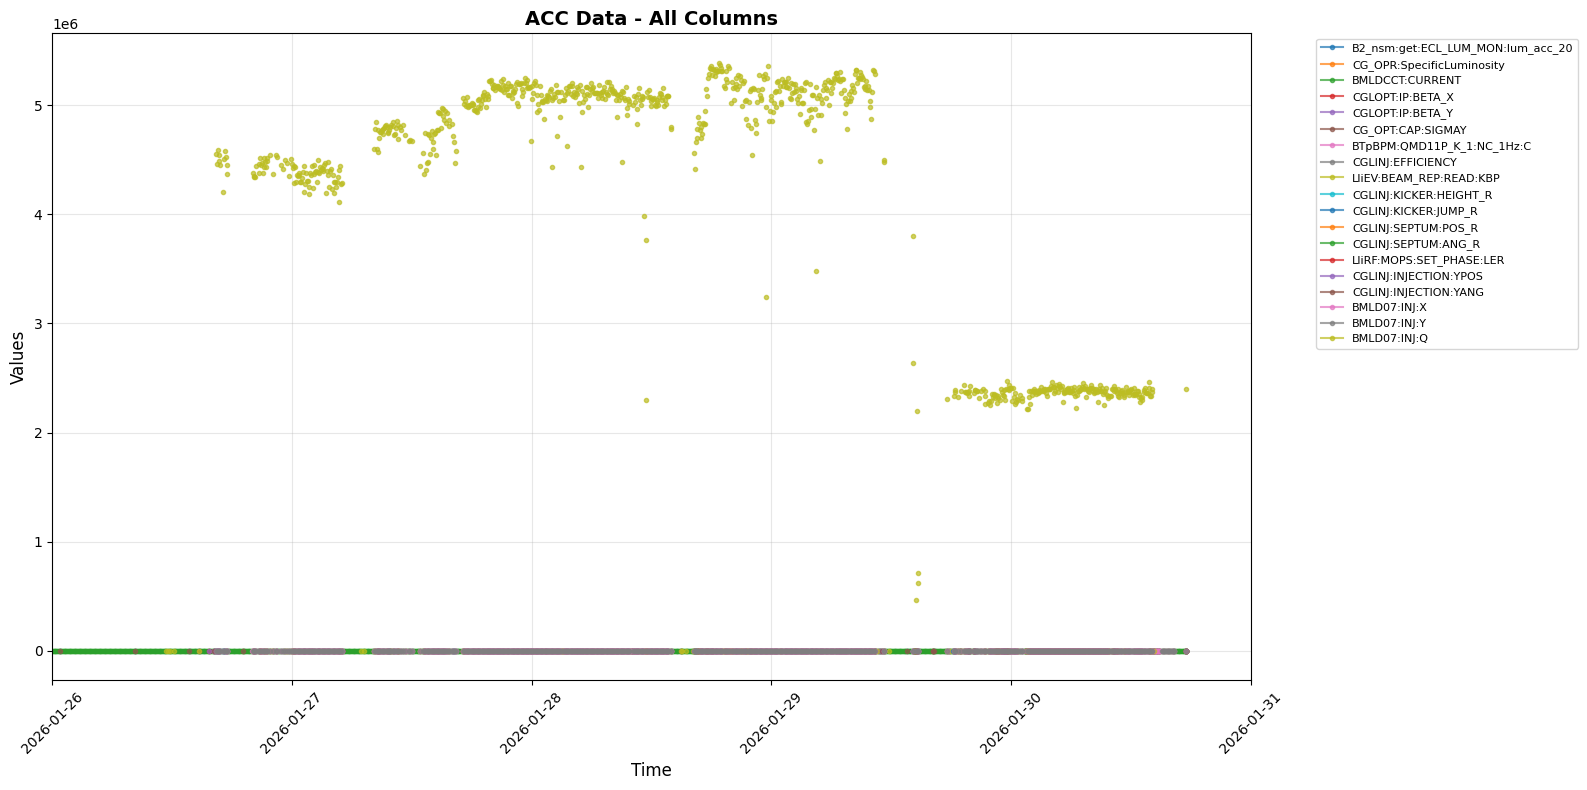

Plotted 19 columns from ACC data


In [56]:
# Plot all ACC data columns together
fig, ax = plt.subplots(figsize=(16, 8))

# Get all numeric columns (exclude Timestamp)
acc_numeric_cols = acc_df1.select_dtypes(include=[np.number]).columns.tolist()

# Plot each column
for col in acc_numeric_cols:
    ax.plot(acc_df1['Timestamp'], acc_df1[col], label=col, marker='o', markersize=3, alpha=0.7)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Values', fontsize=12)
ax.set_title('ACC Data - All Columns', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE) + pd.Timedelta(days=1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Plotted {len(acc_numeric_cols)} columns from ACC data")

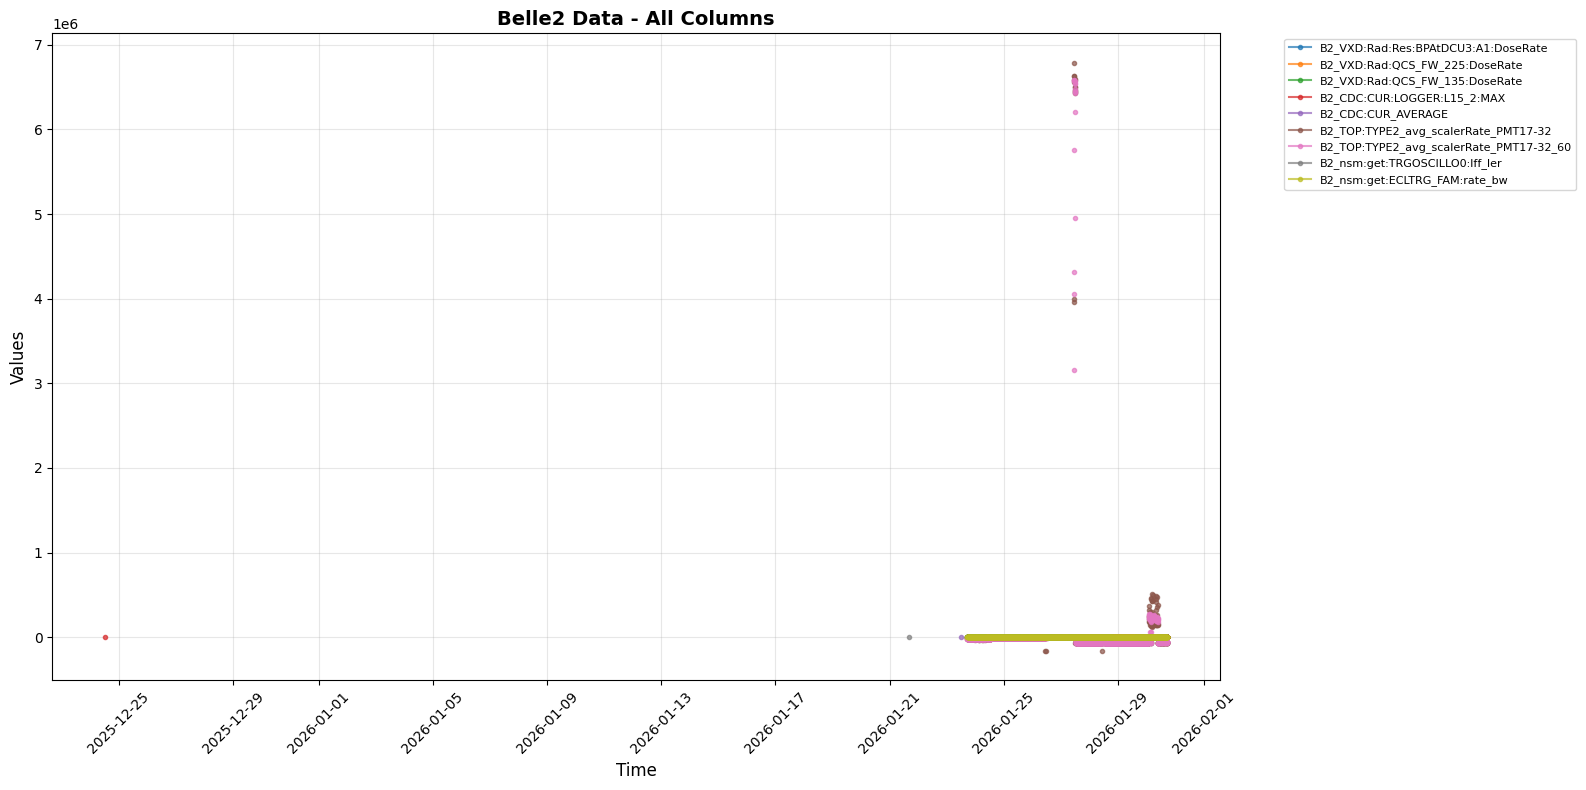

Plotted 9 columns from Belle2 data


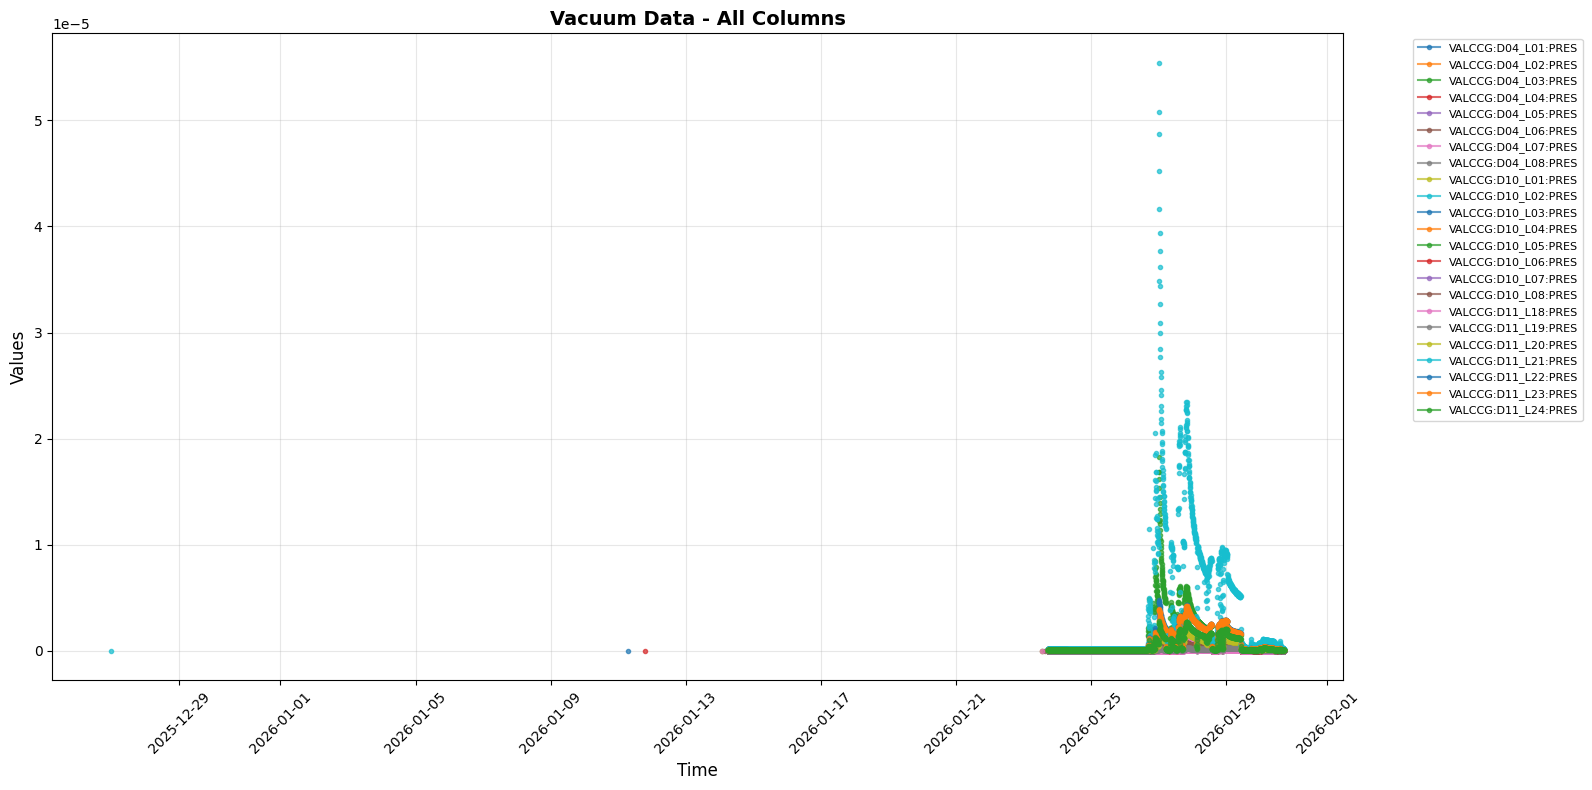

Plotted 23 columns from Vacuum data


In [ ]:
# Plot all Belle2 data columns together
fig, ax = plt.subplots(figsize=(16, 8))

# Get all numeric columns (exclude Timestamp)
belle2_numeric_cols = belle2_df.select_dtypes(include=[np.number]).columns.tolist()

# Plot each column
for col in belle2_numeric_cols:
    ax.plot(belle2_df['Timestamp'], belle2_df[col], label=col, marker='o', markersize=3, alpha=0.7)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Values', fontsize=12)
ax.set_title('Belle2 Data - All Columns', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE) + pd.Timedelta(days=1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Plotted {len(belle2_numeric_cols)} columns from Belle2 data")

# Plot all Vacuum data columns together
fig, ax = plt.subplots(figsize=(16, 8))

# Get all numeric columns (exclude Timestamp)
vacuum_numeric_cols = vacuum_df.select_dtypes(include=[np.number]).columns.tolist()

# Plot each column
for col in vacuum_numeric_cols:
    ax.plot(vacuum_df['Timestamp'], vacuum_df[col], label=col, marker='o', markersize=3, alpha=0.7)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Values', fontsize=12)
ax.set_title('Vacuum Data - All Columns', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE) + pd.Timedelta(days=1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Plotted {len(vacuum_numeric_cols)} columns from Vacuum data")

Creating individual plots for each column...


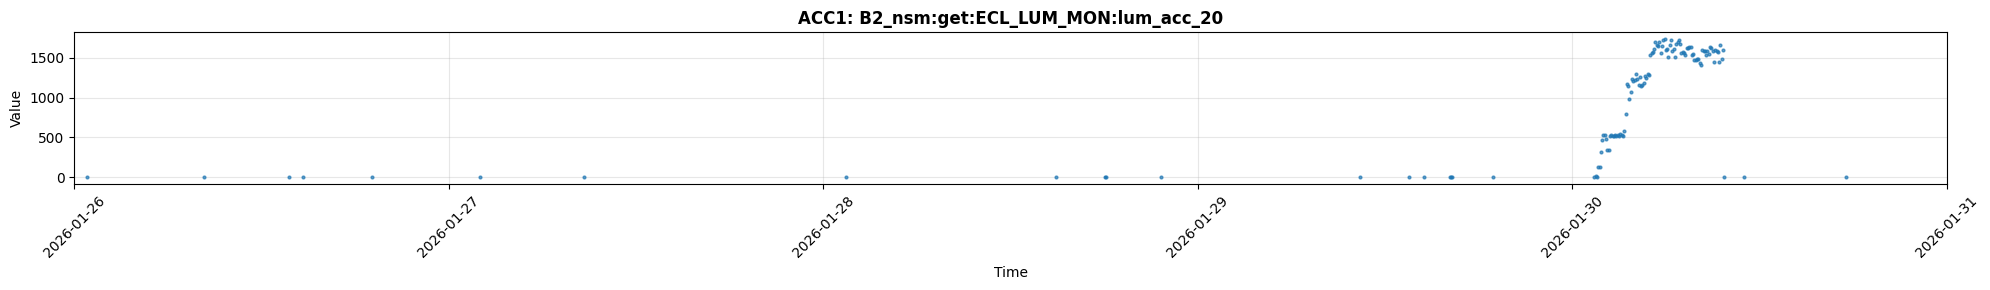

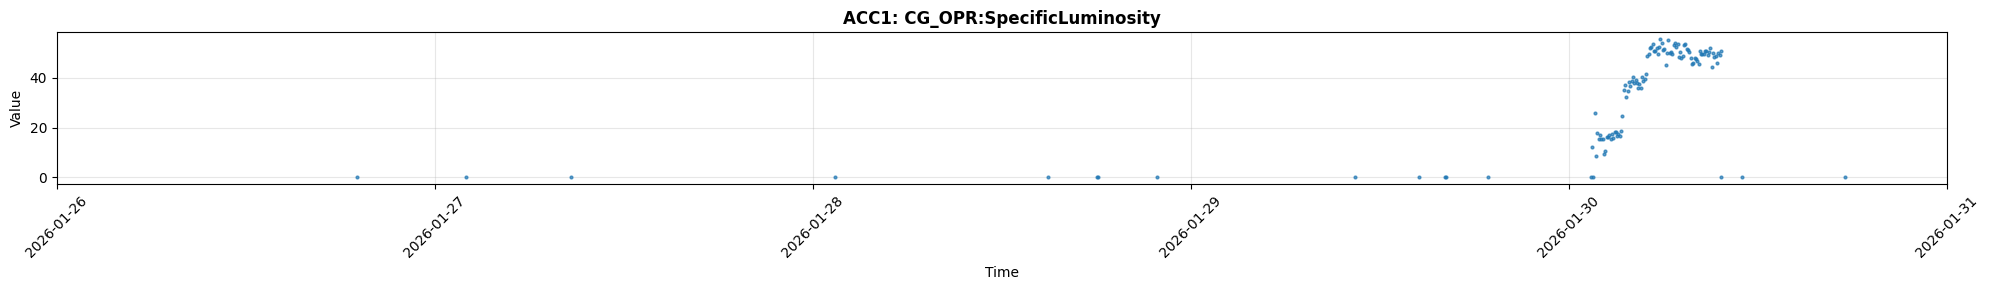

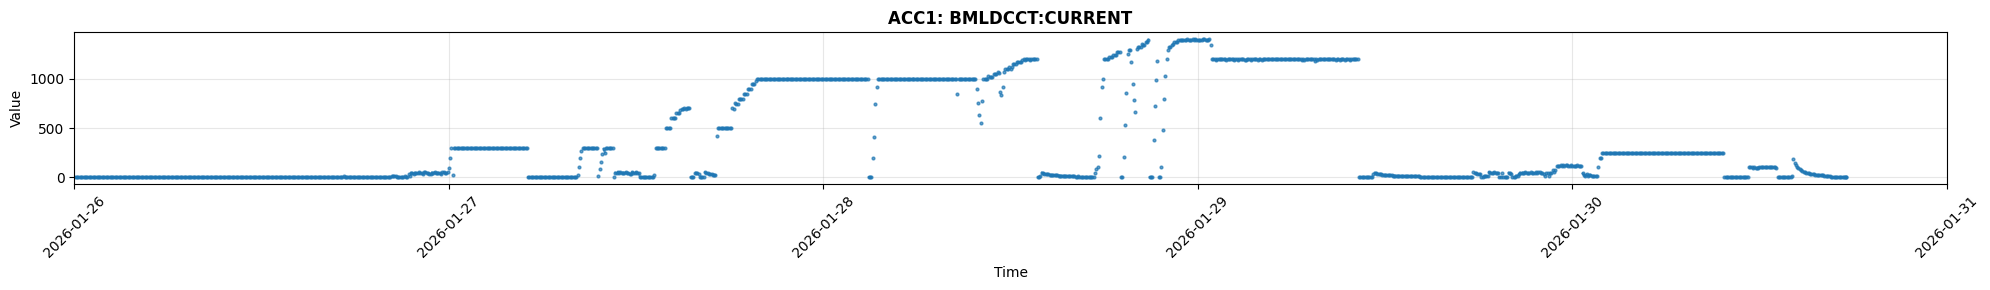

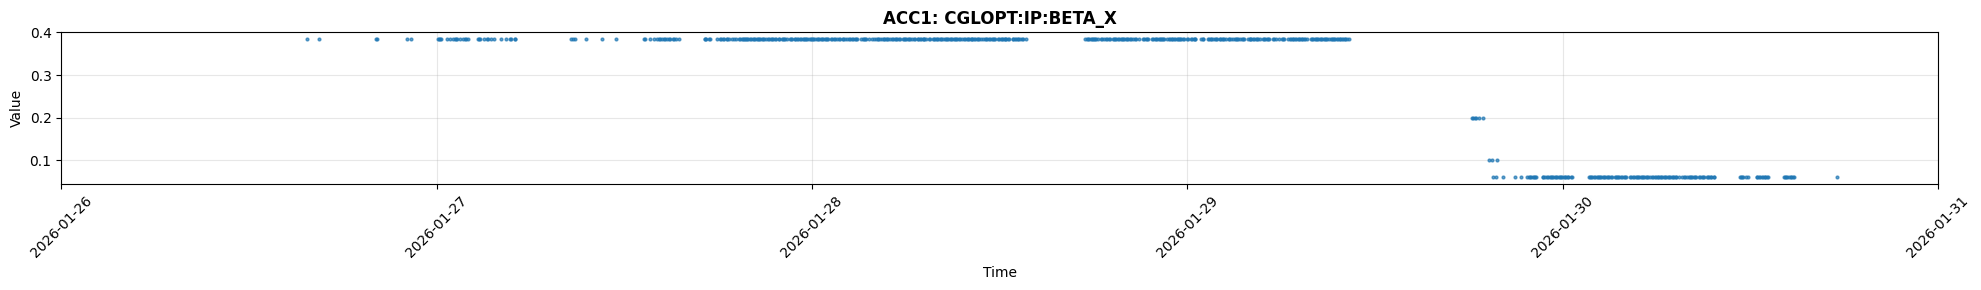

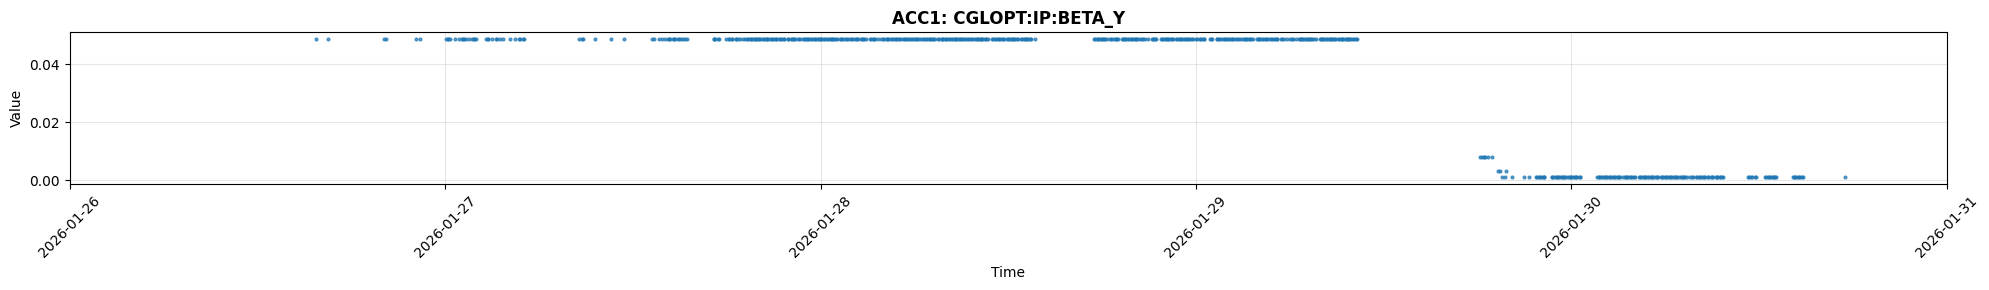

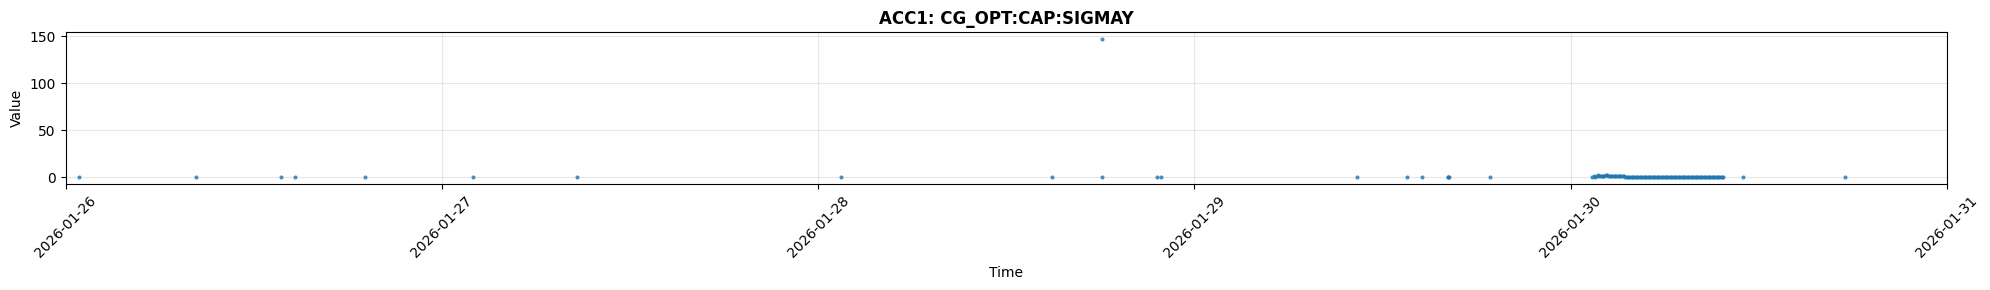

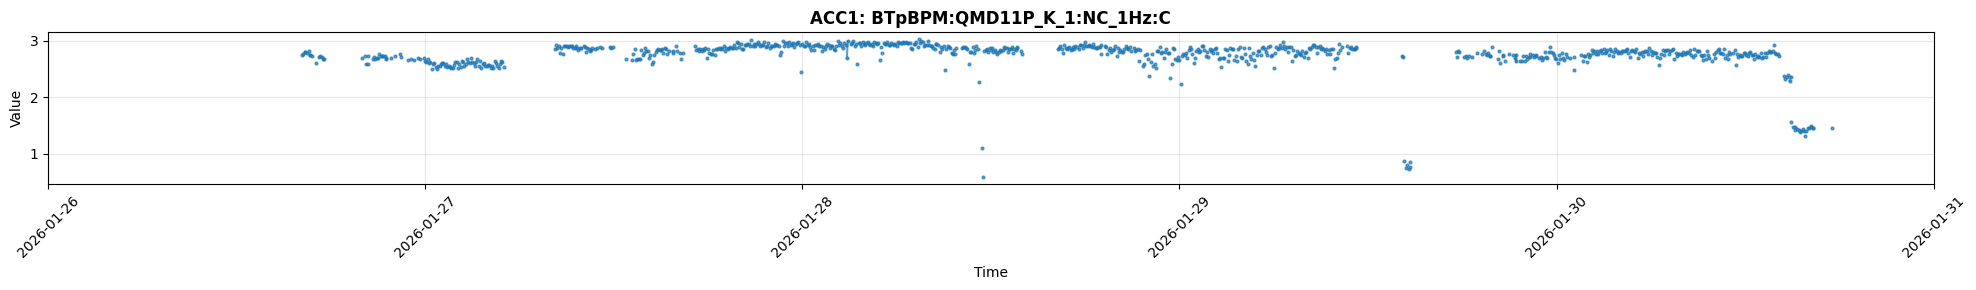

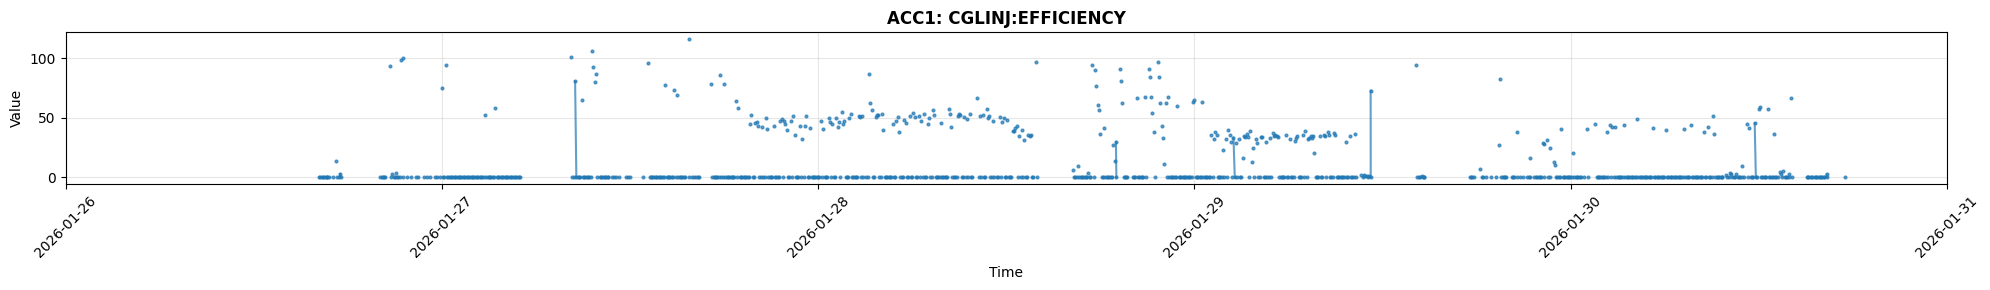

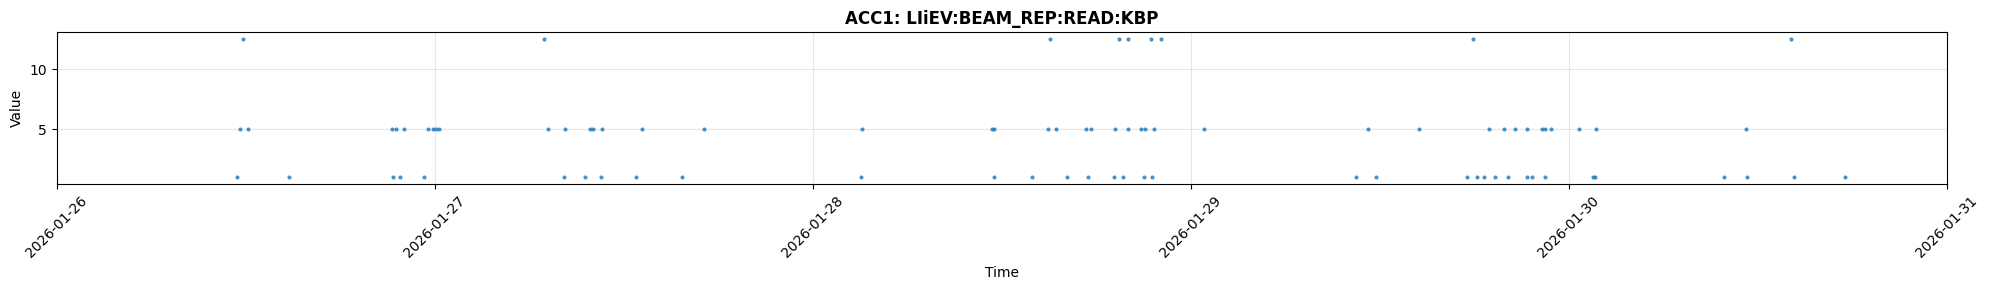

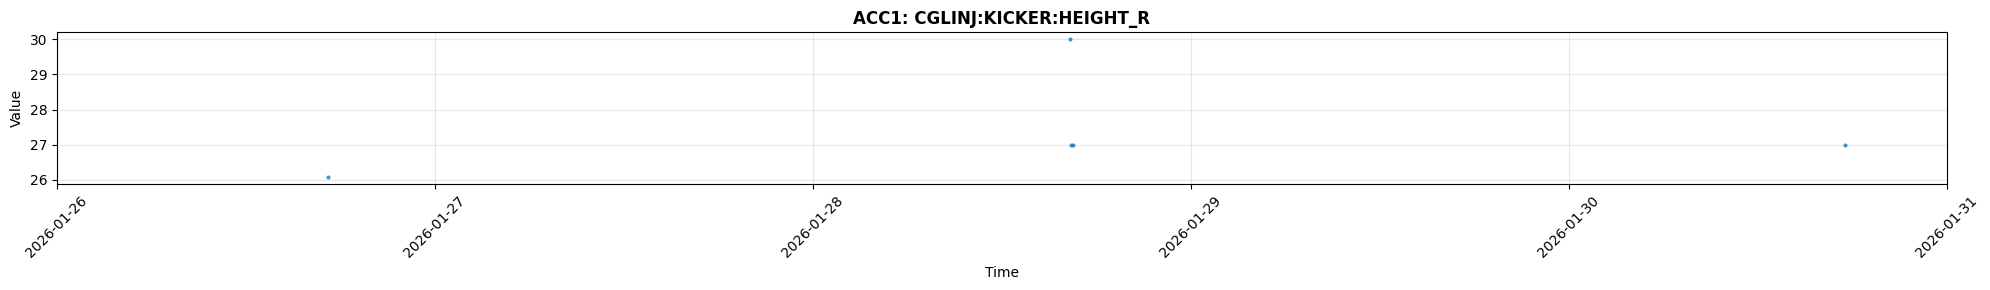

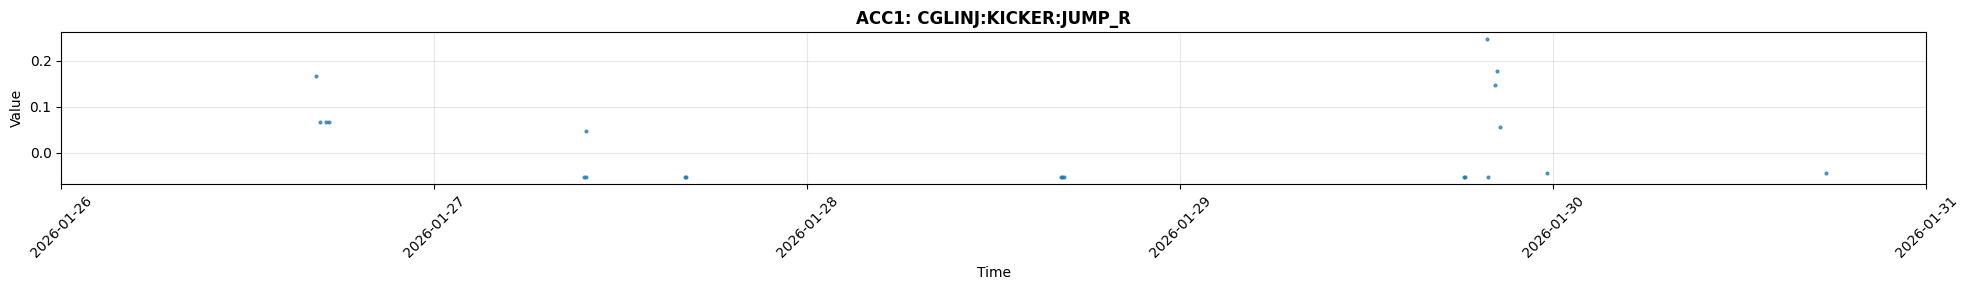

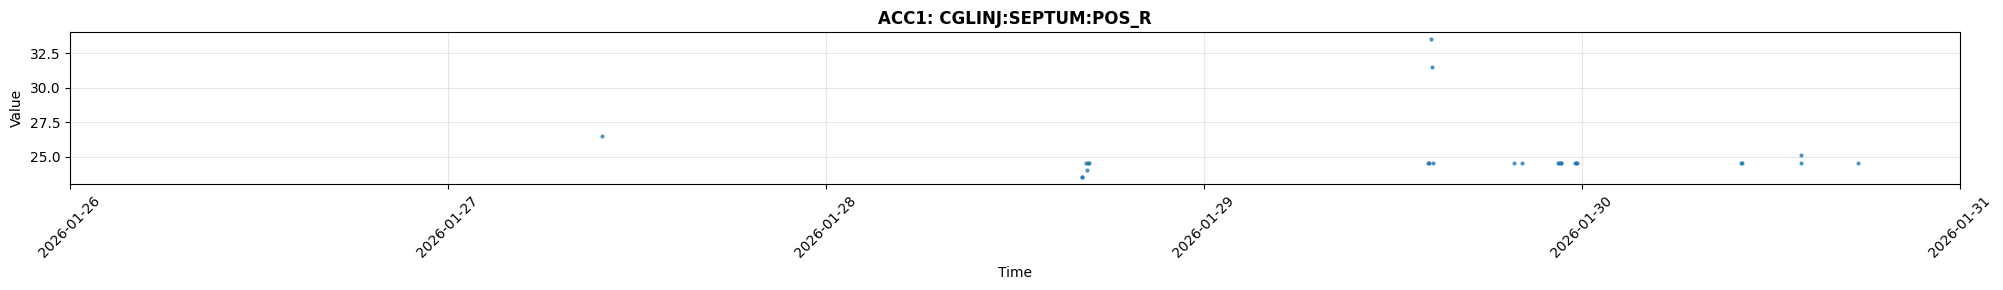

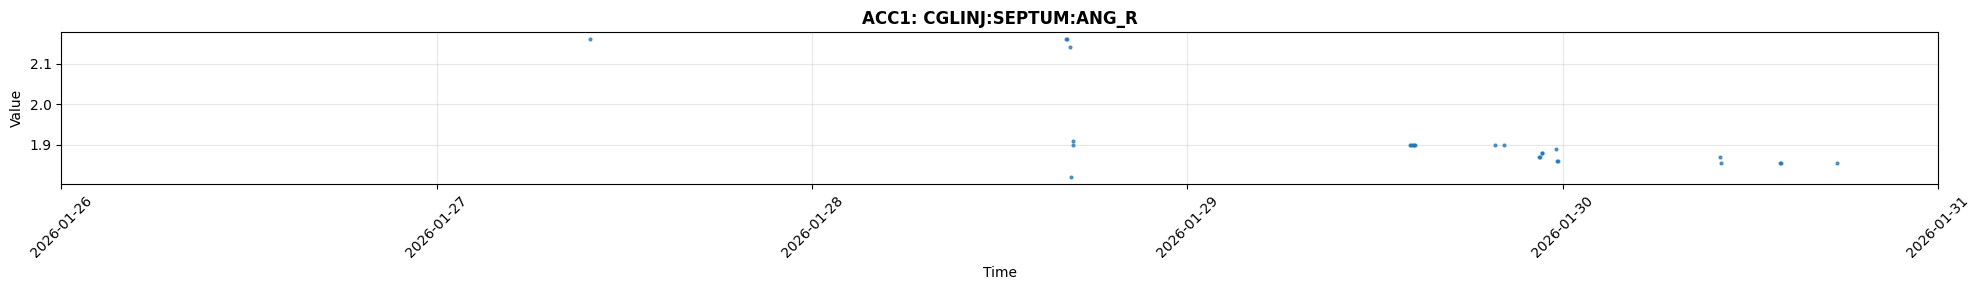

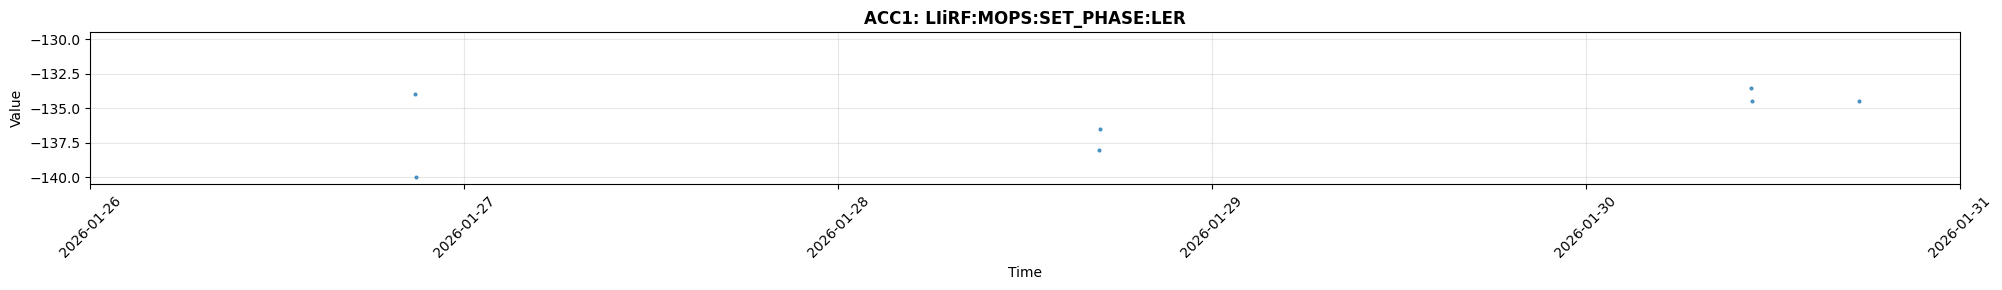

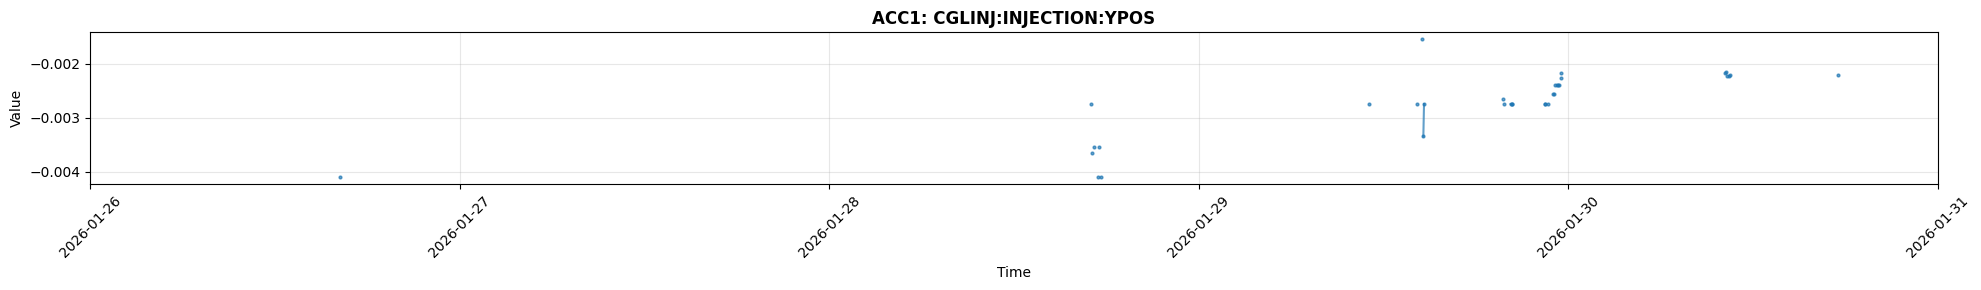

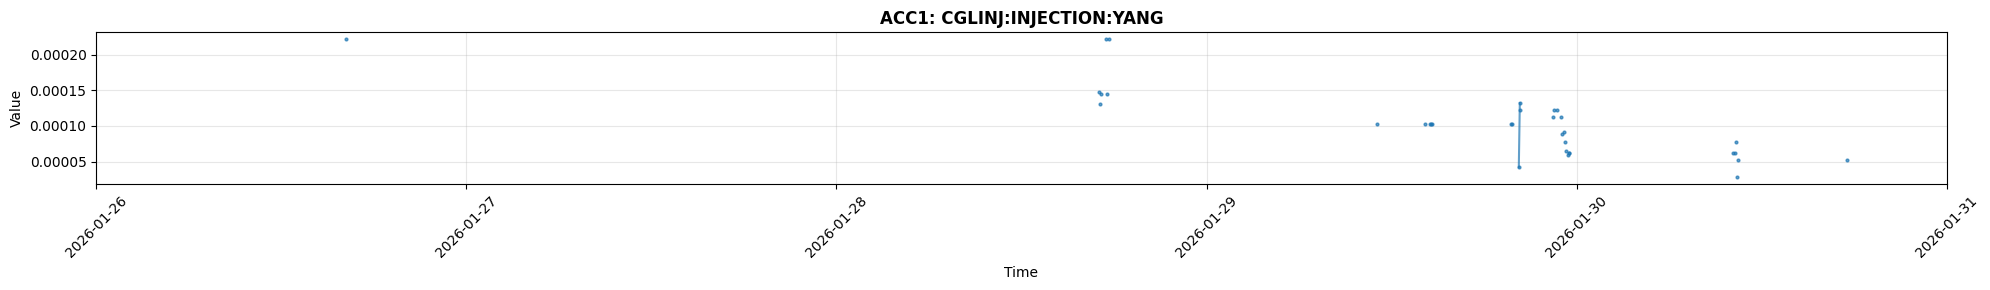

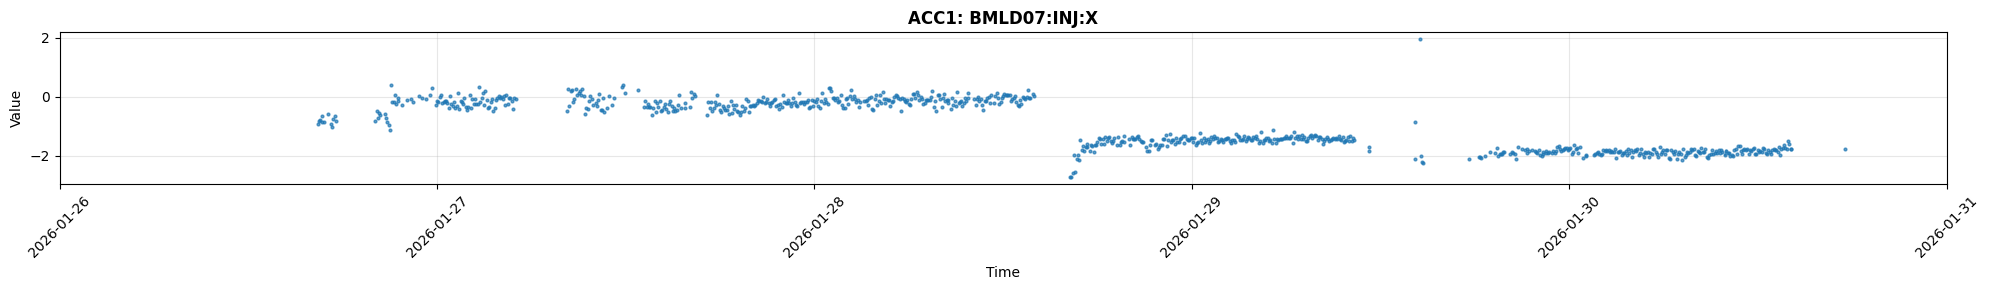

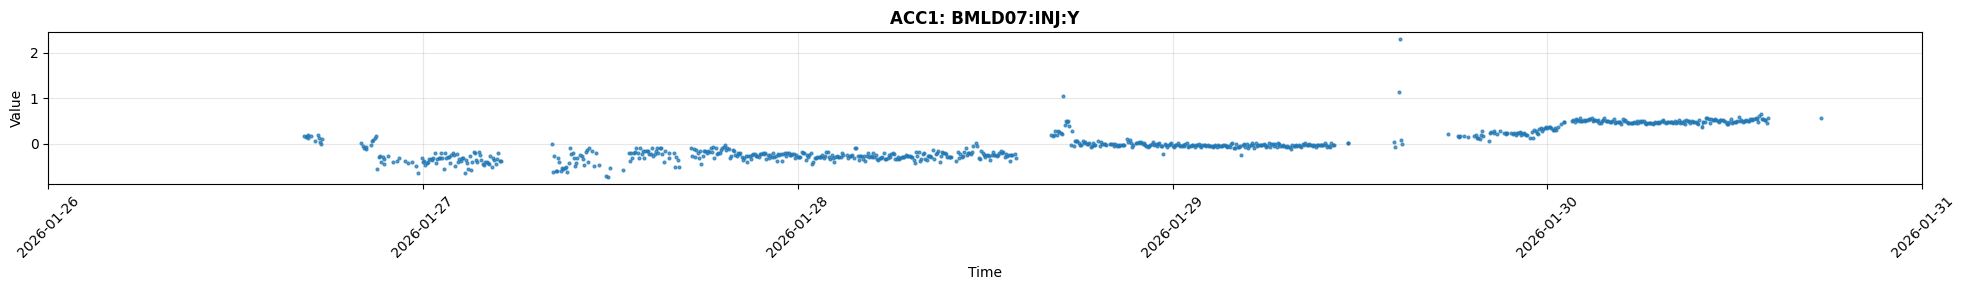

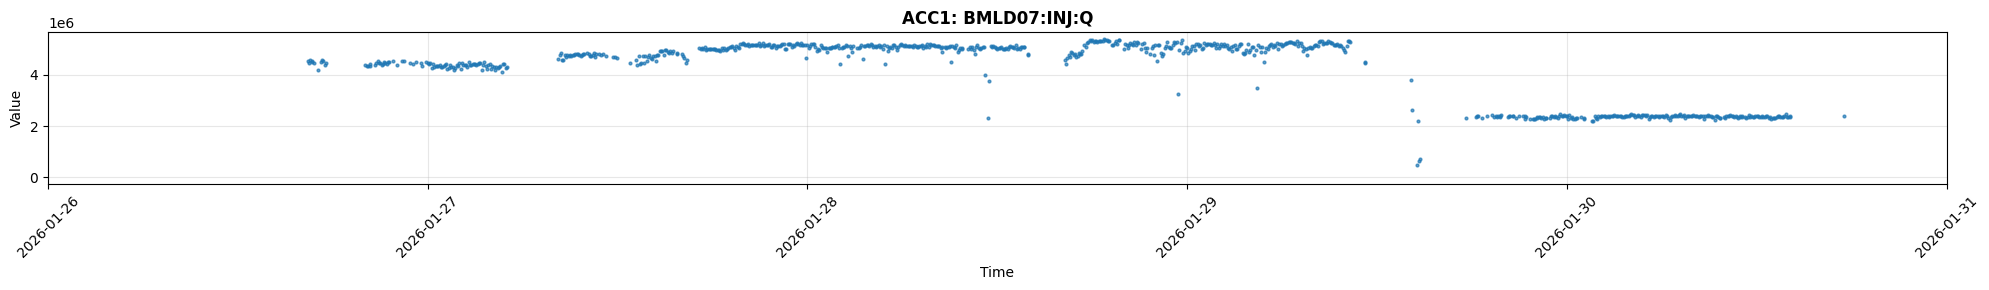

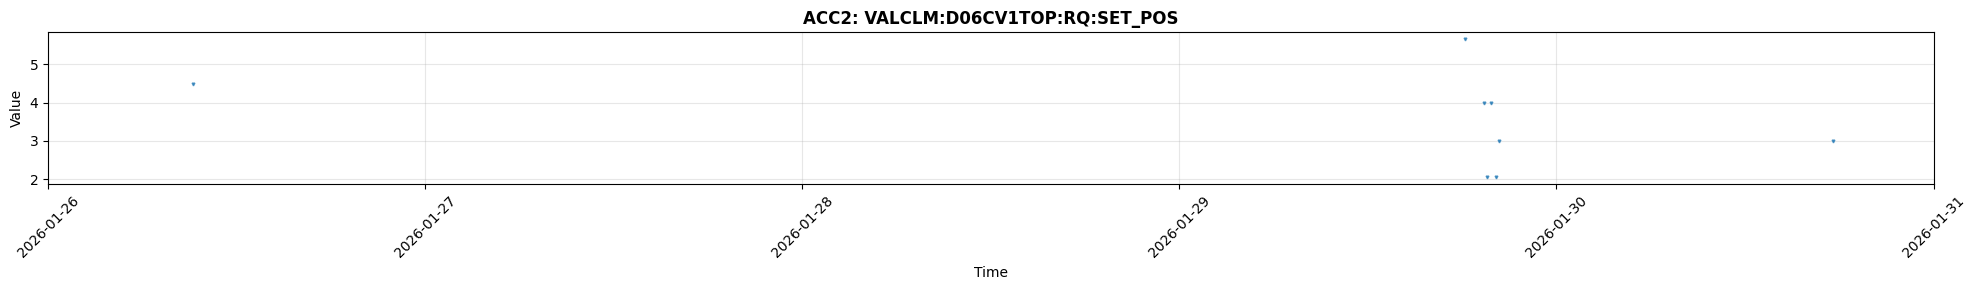

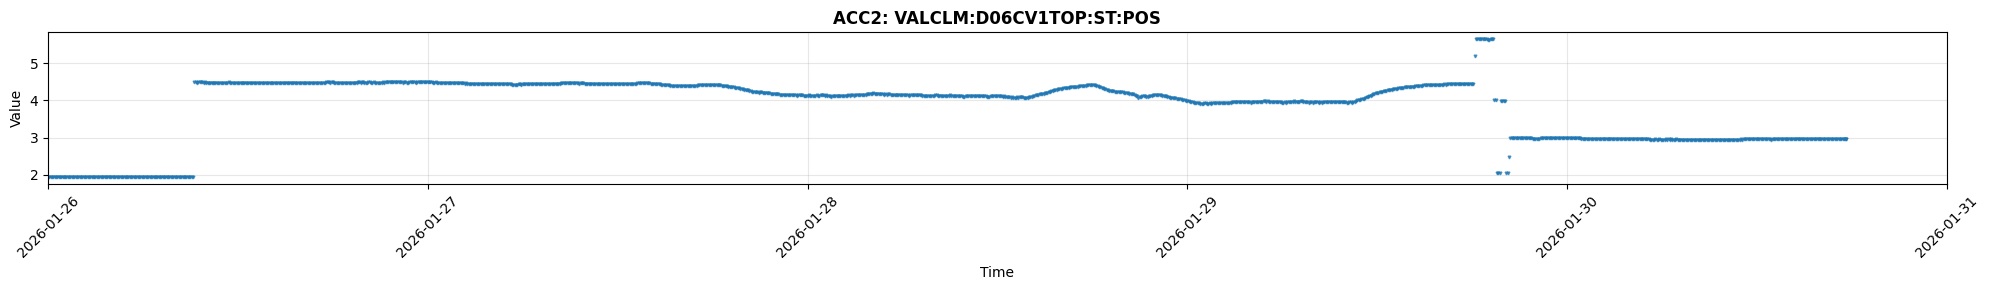

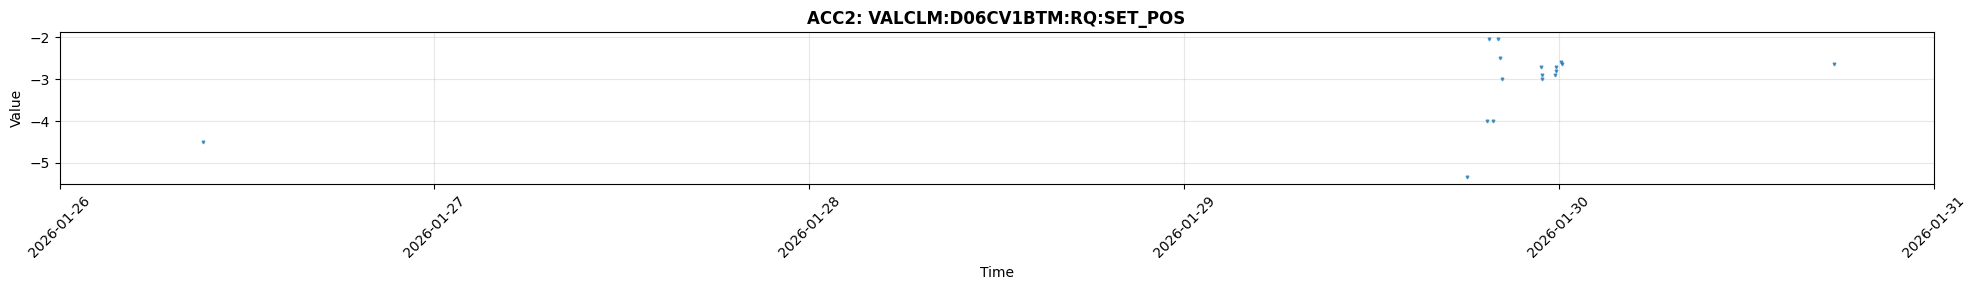

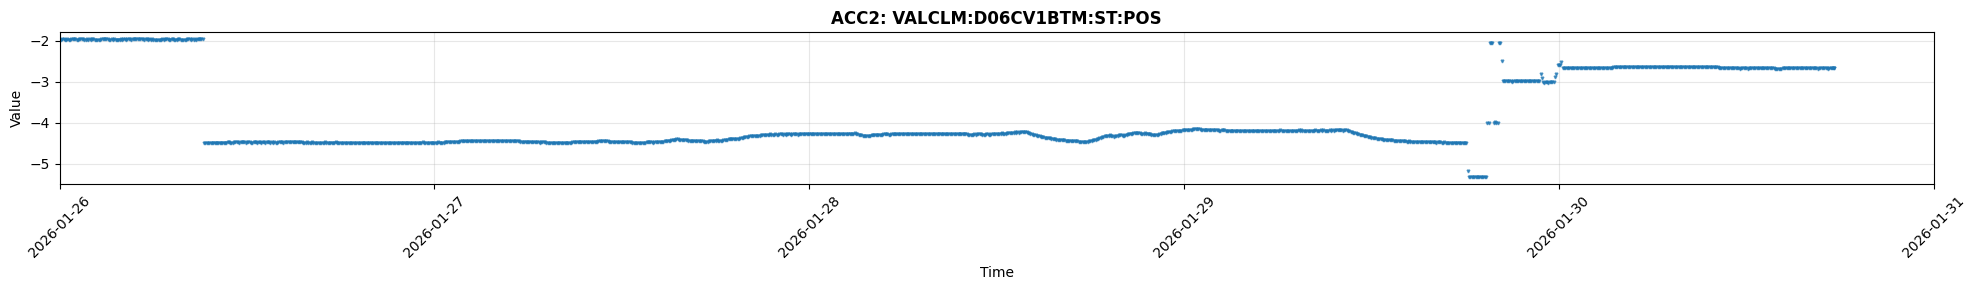

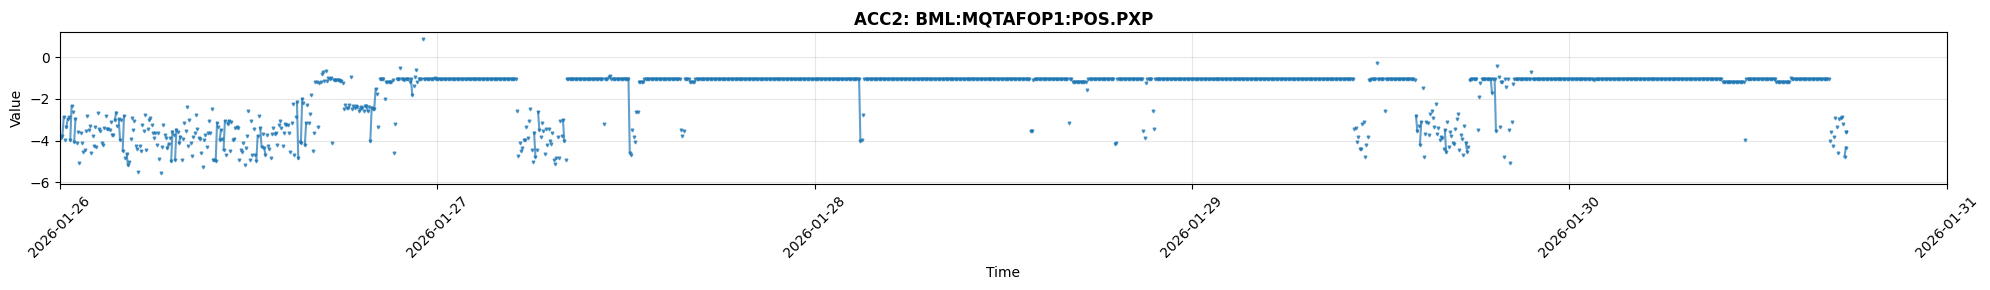

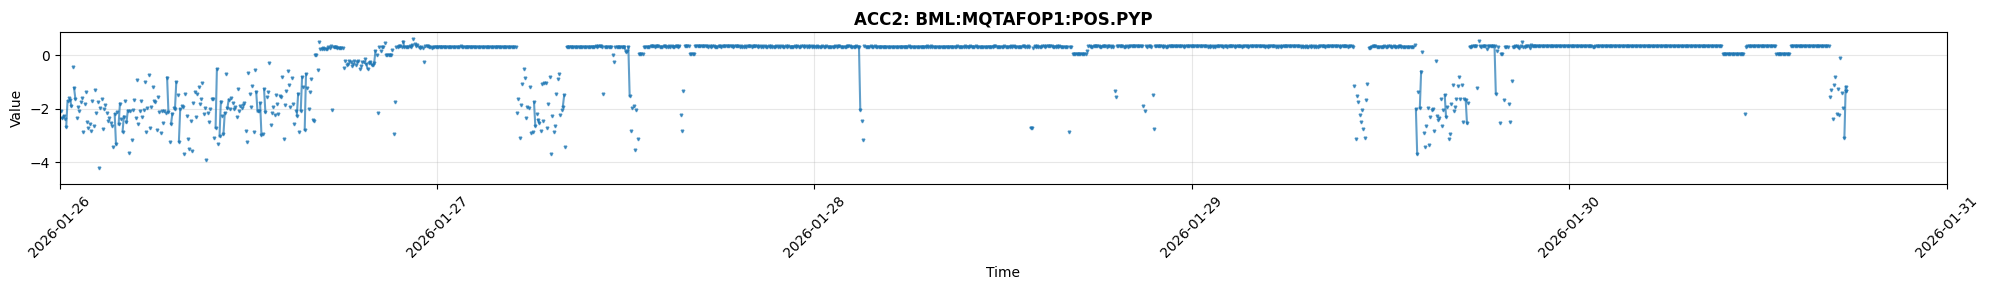

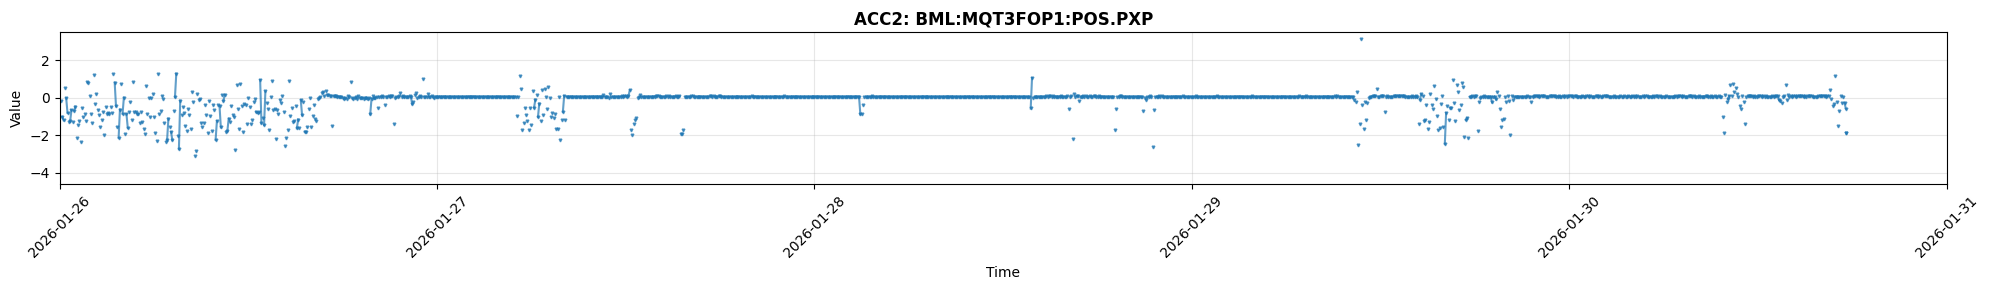

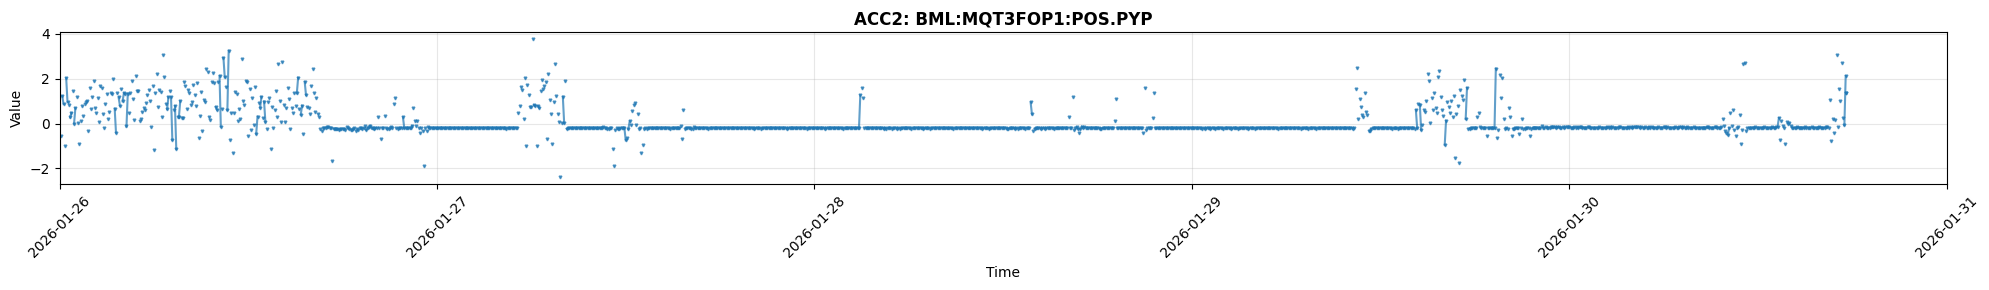

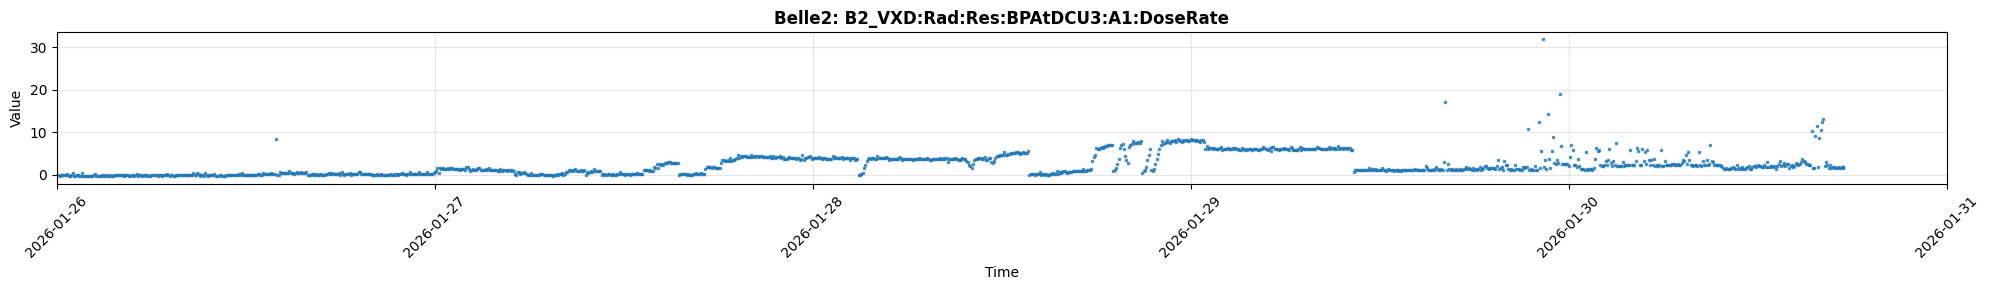

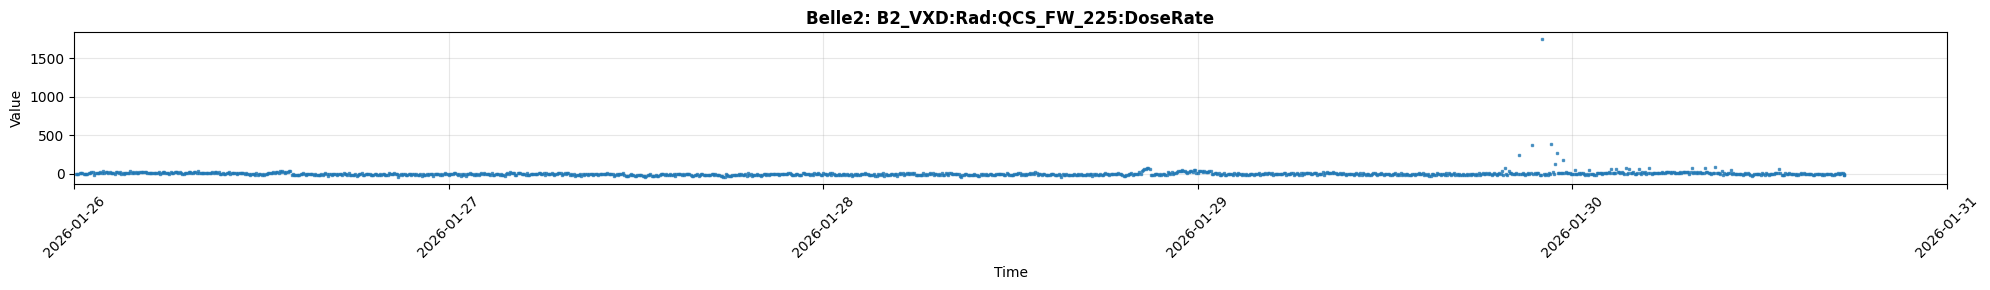

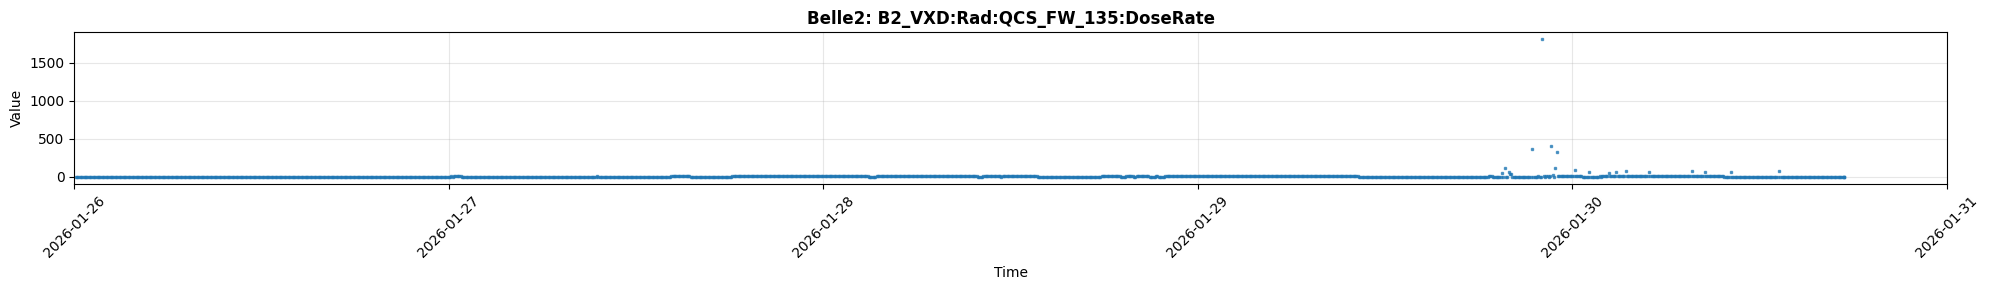

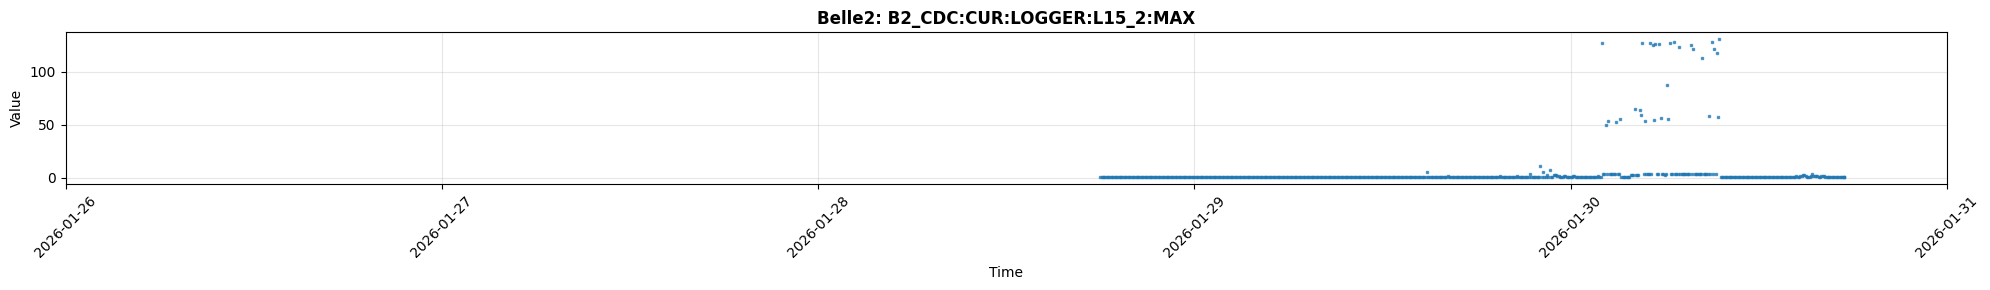

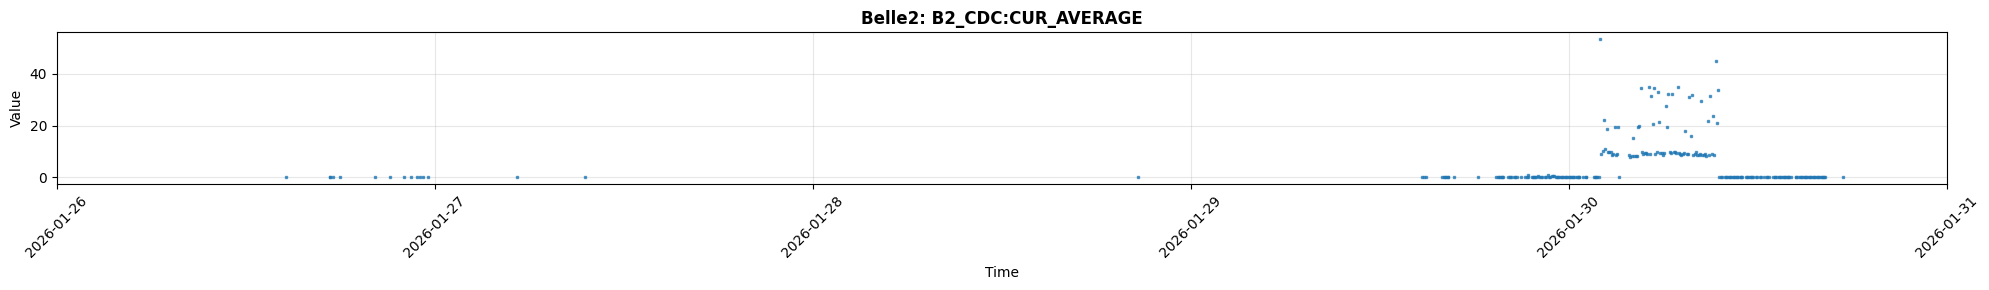

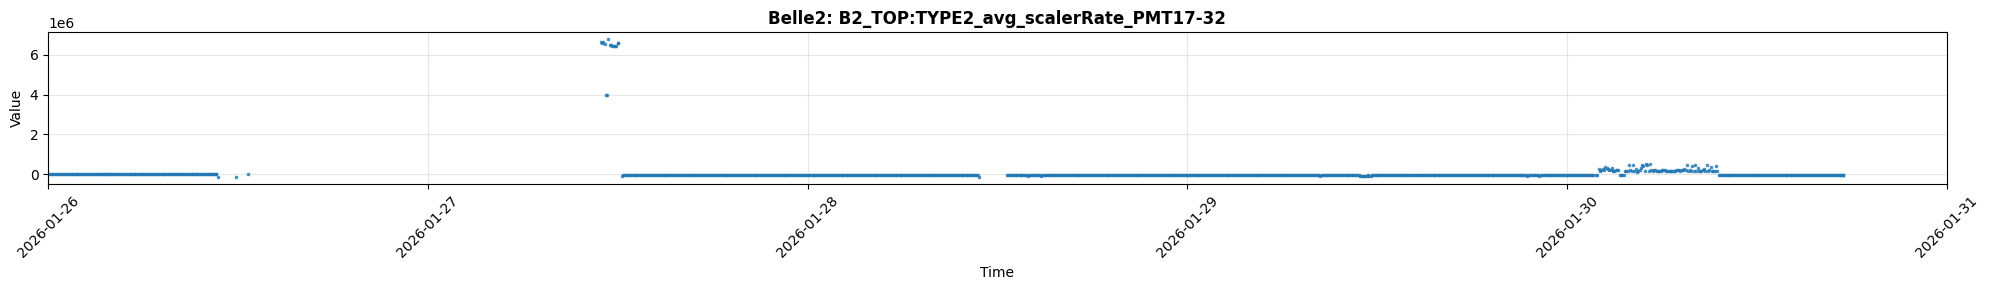

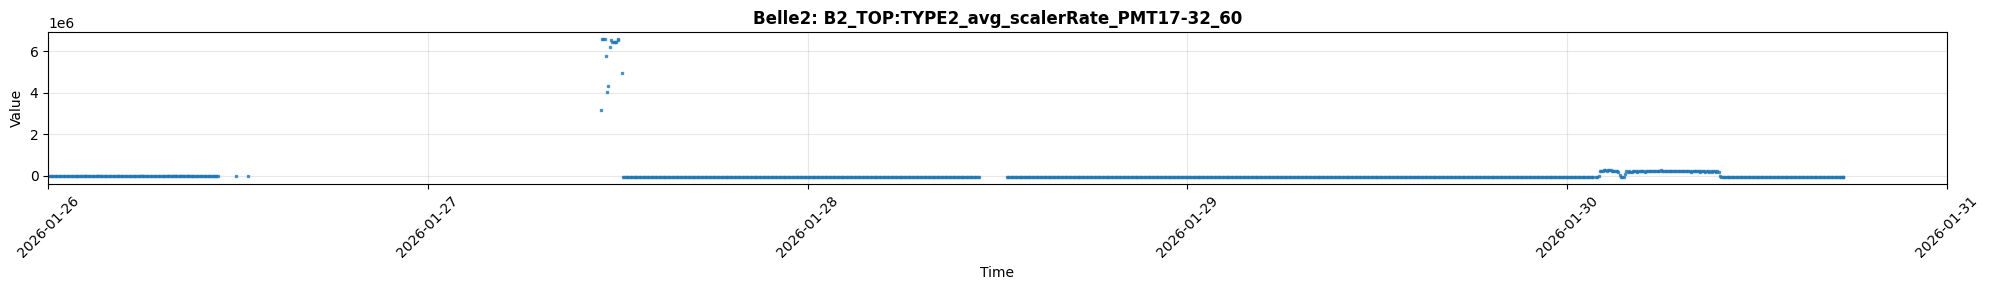

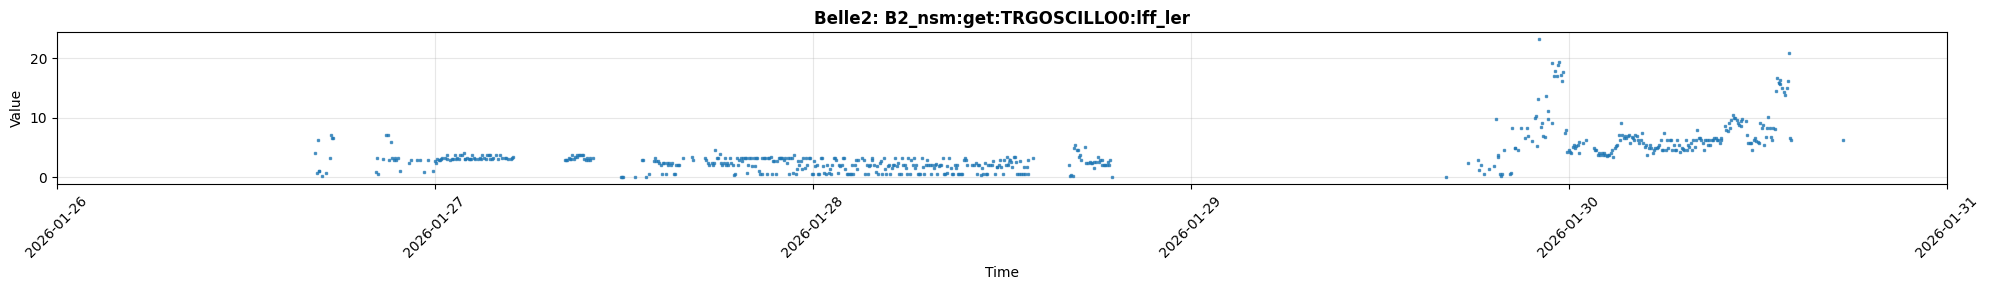

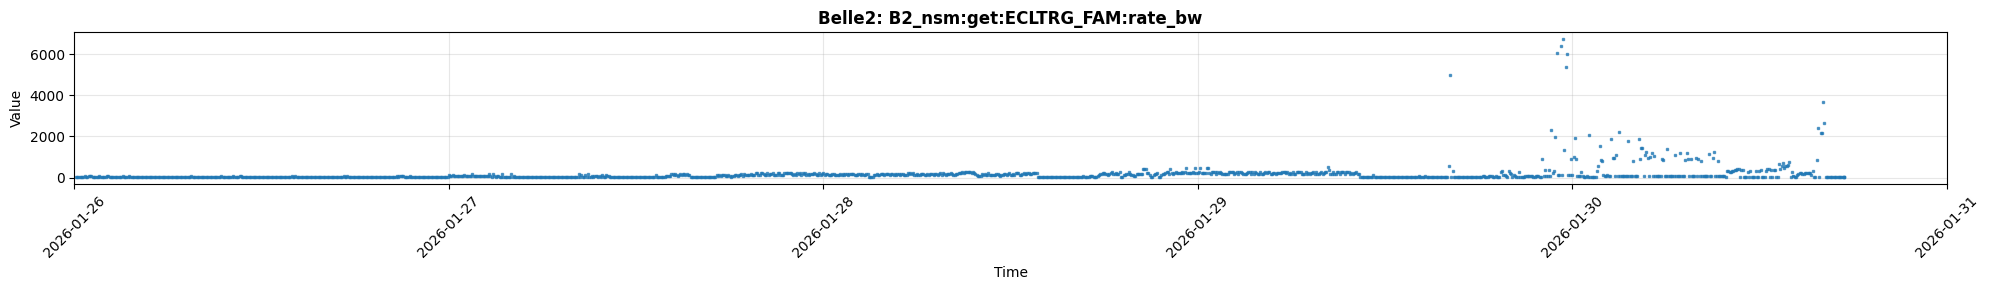

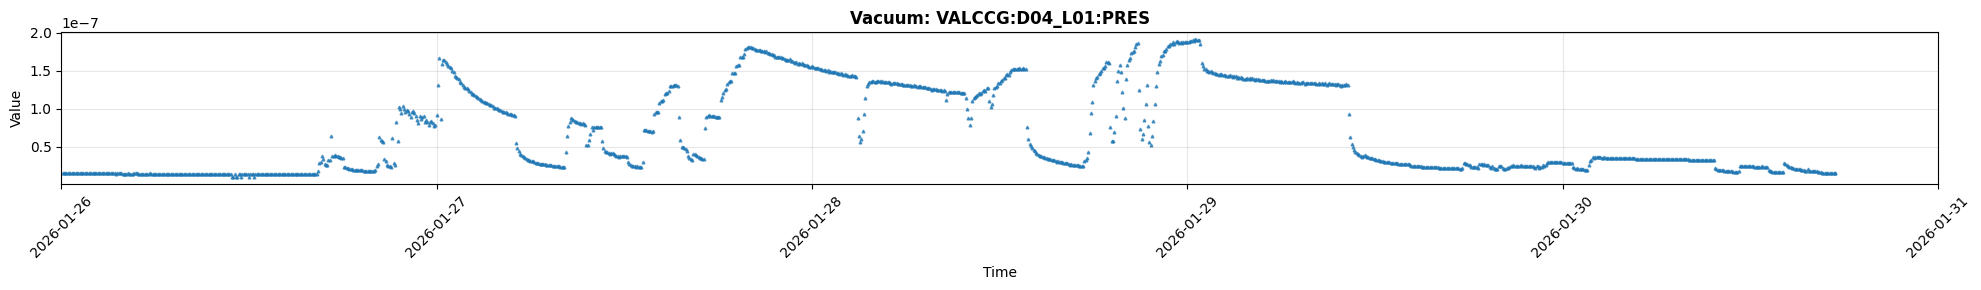

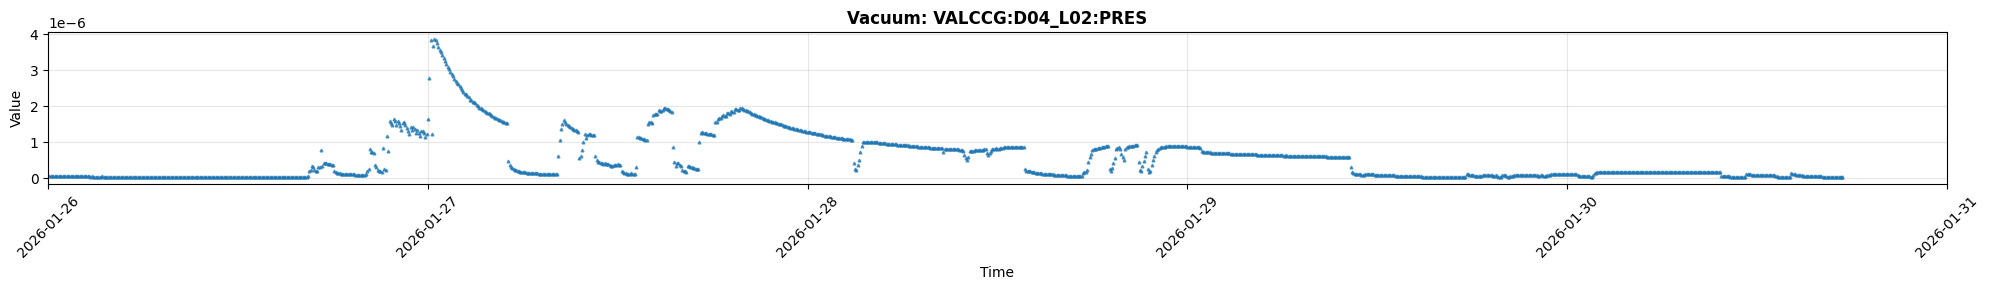

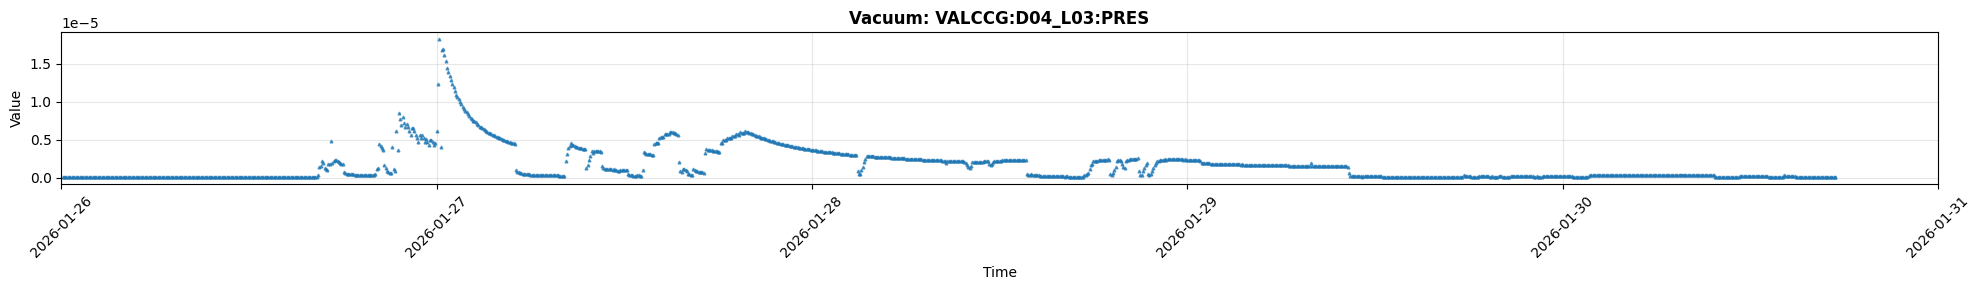

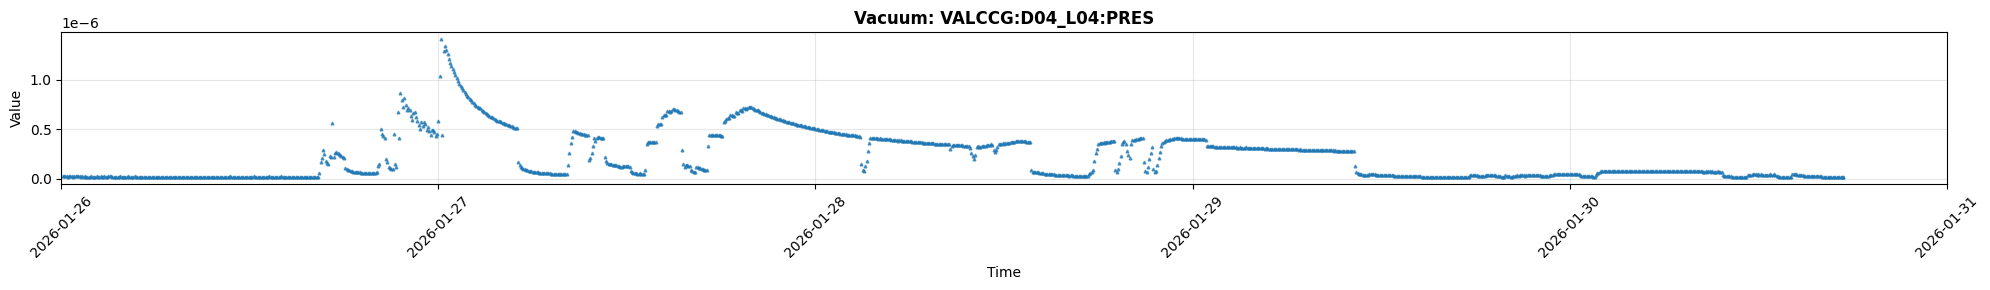

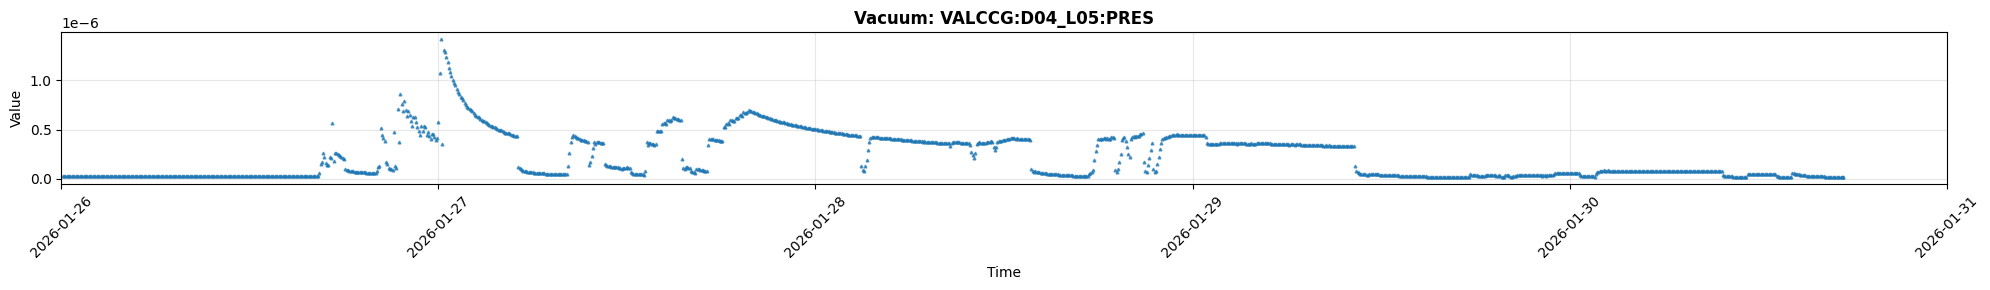

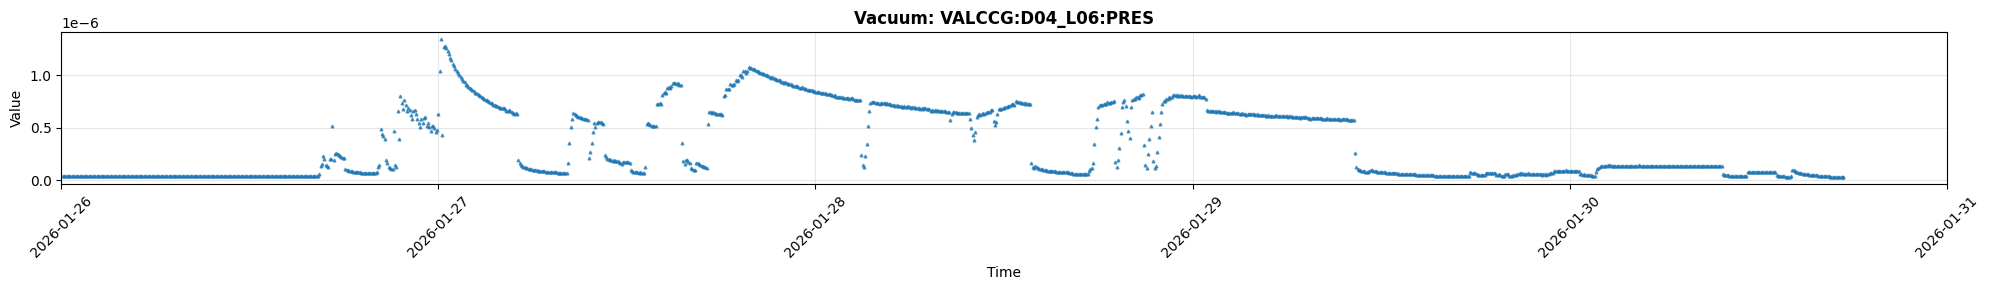

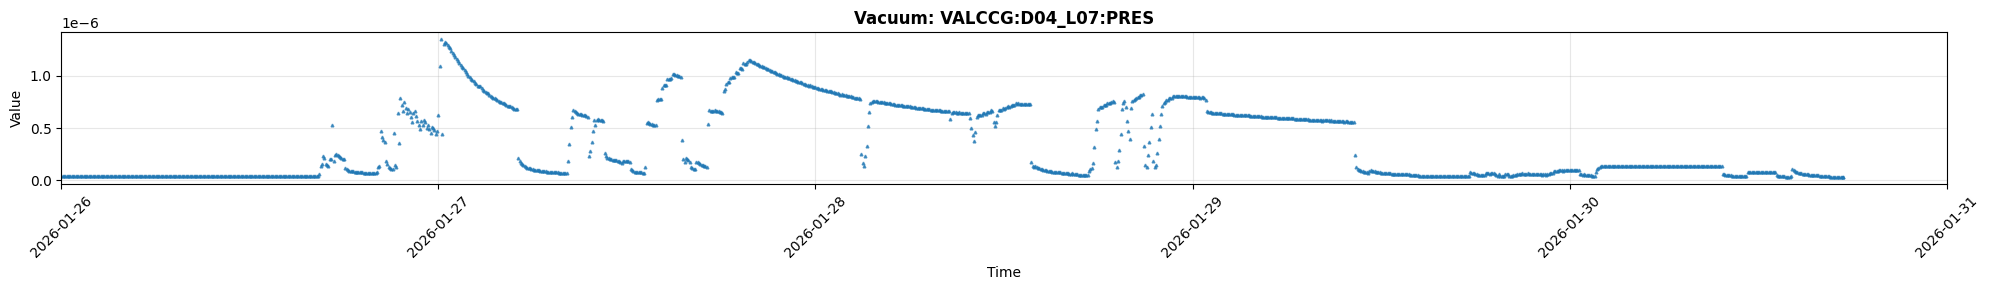

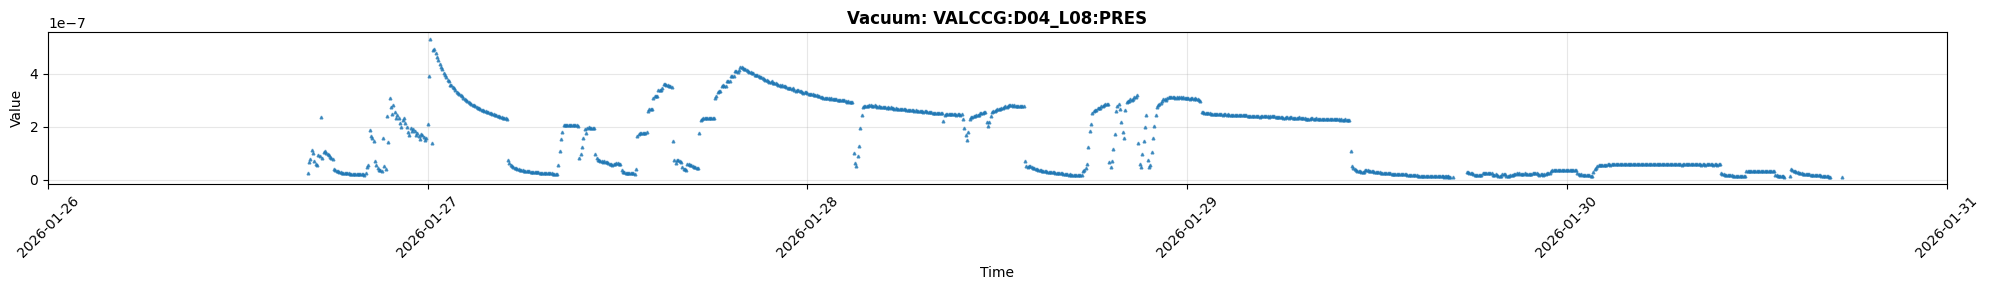

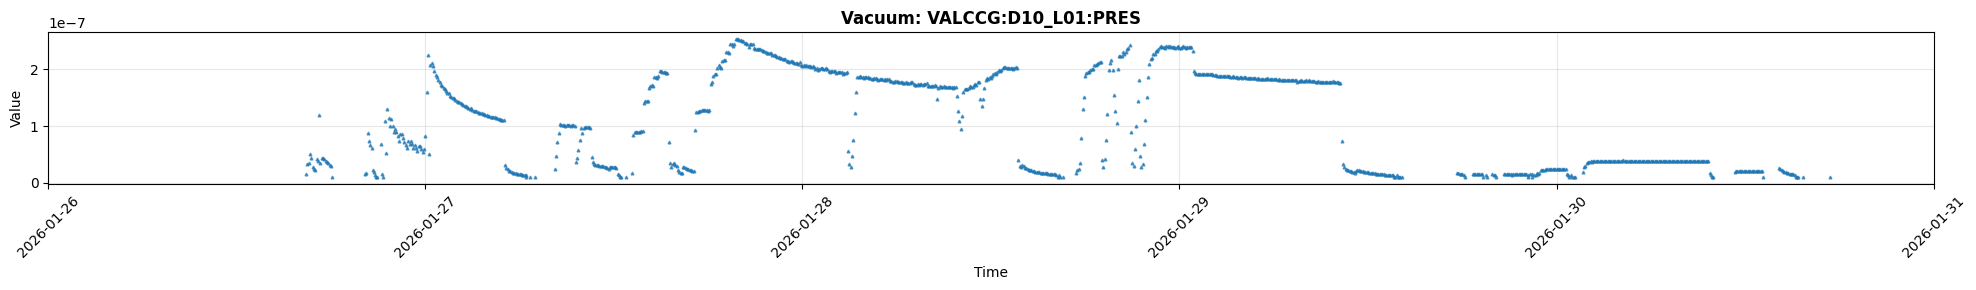

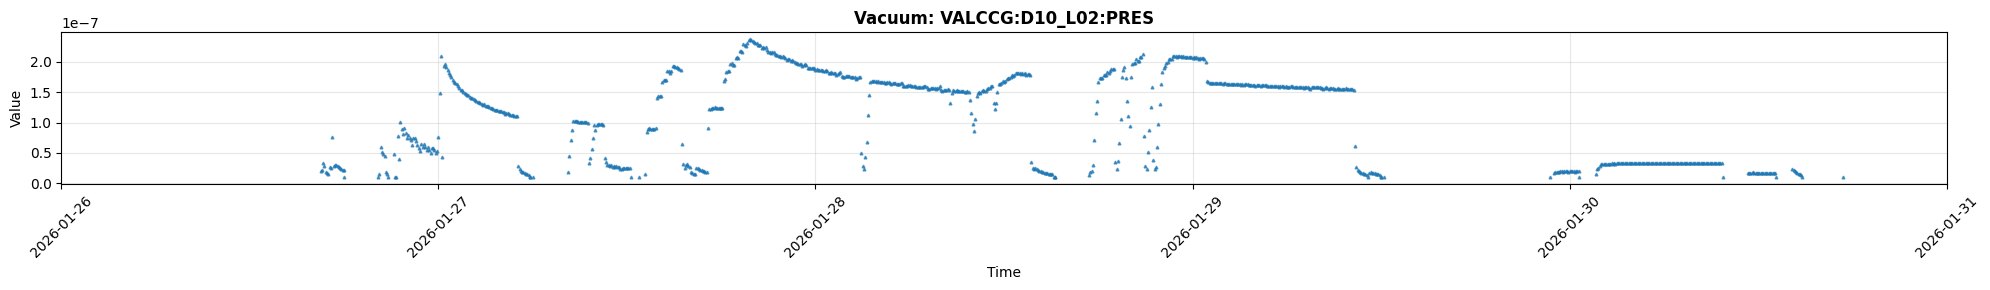

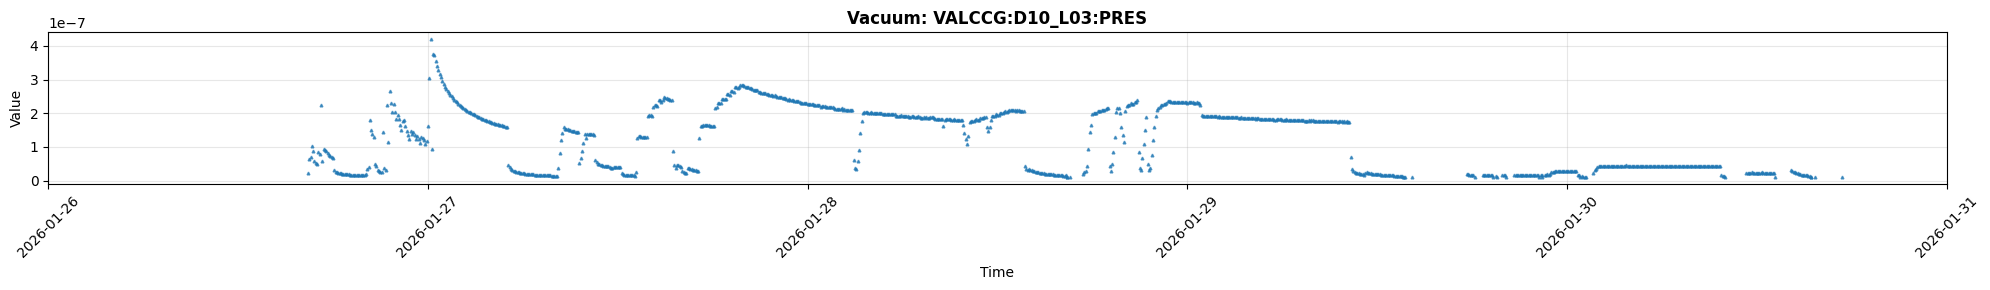

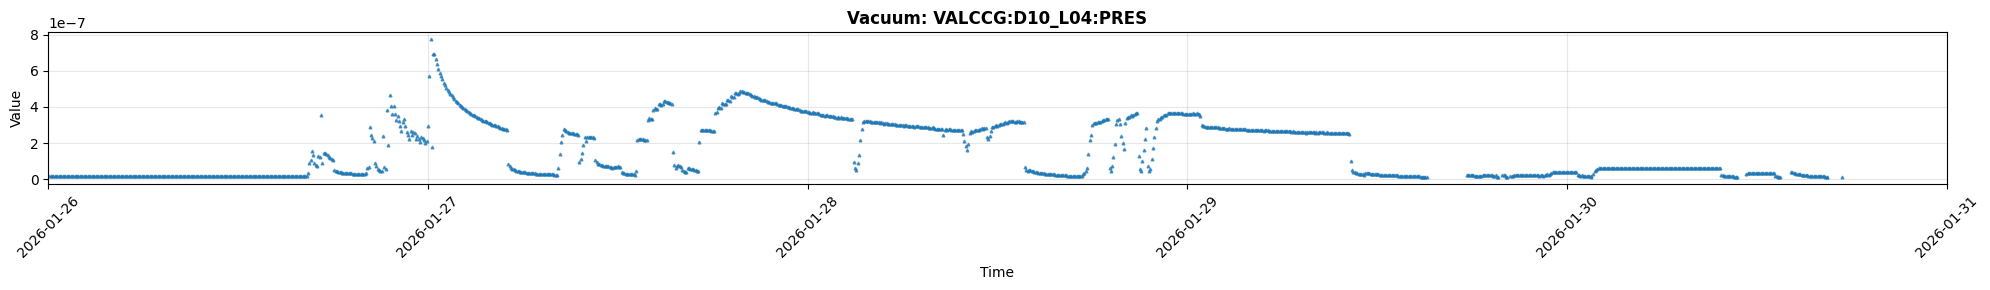

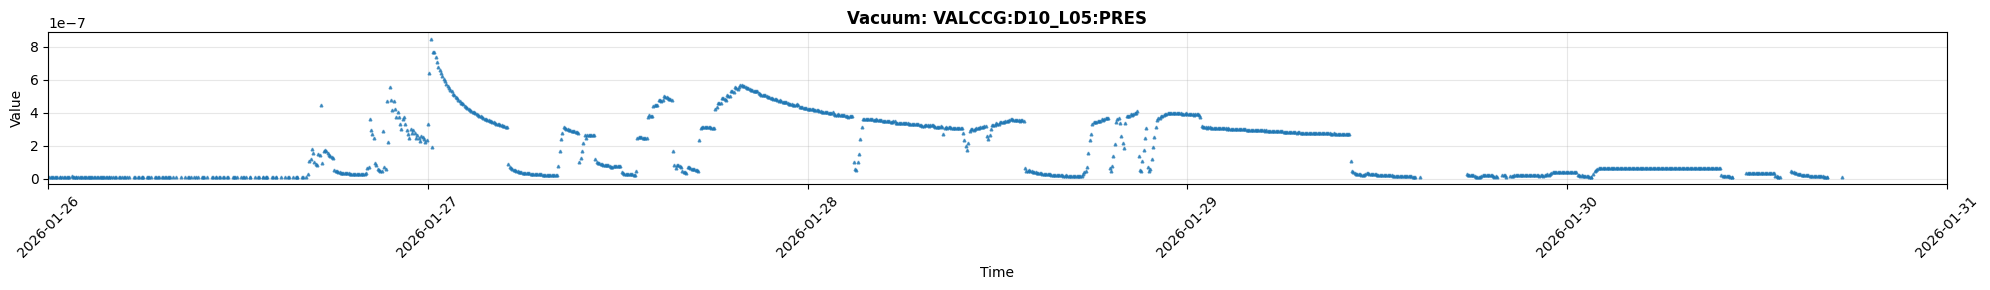

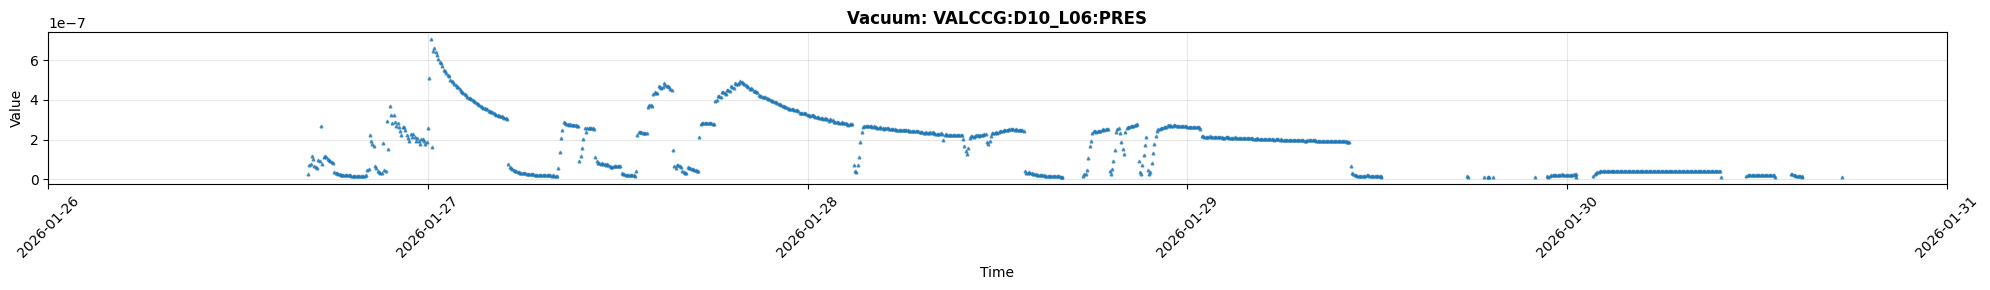

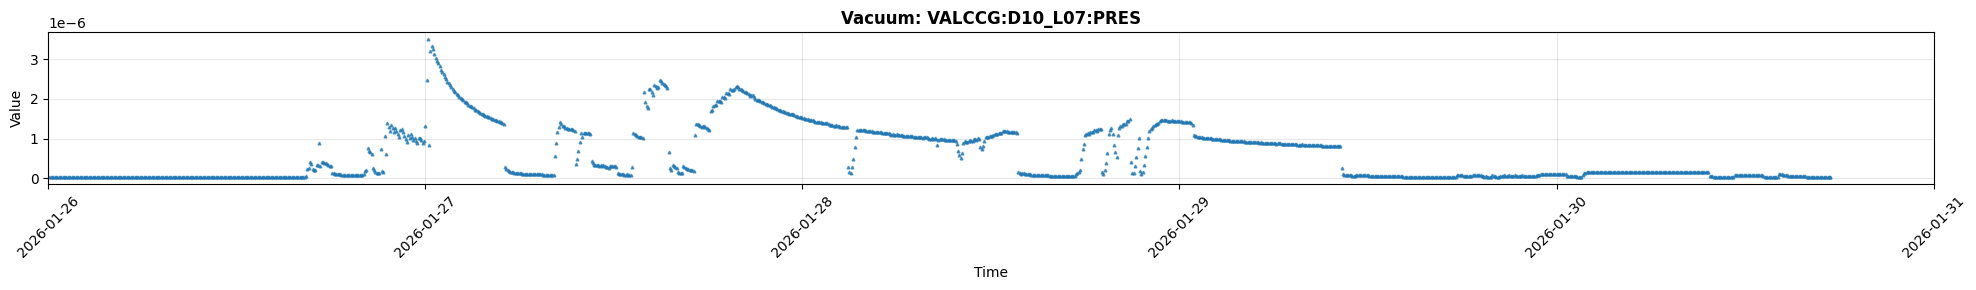

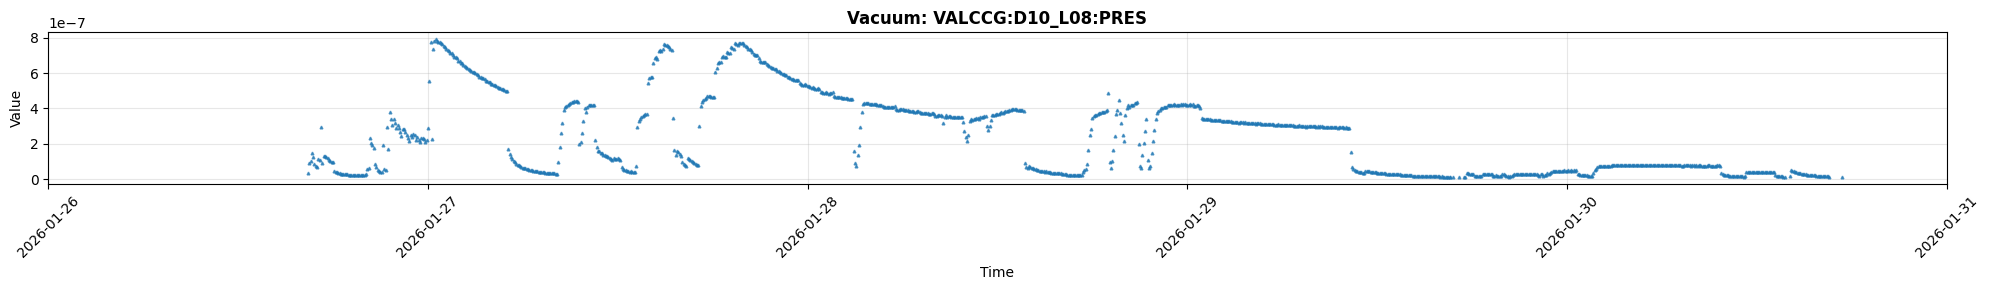

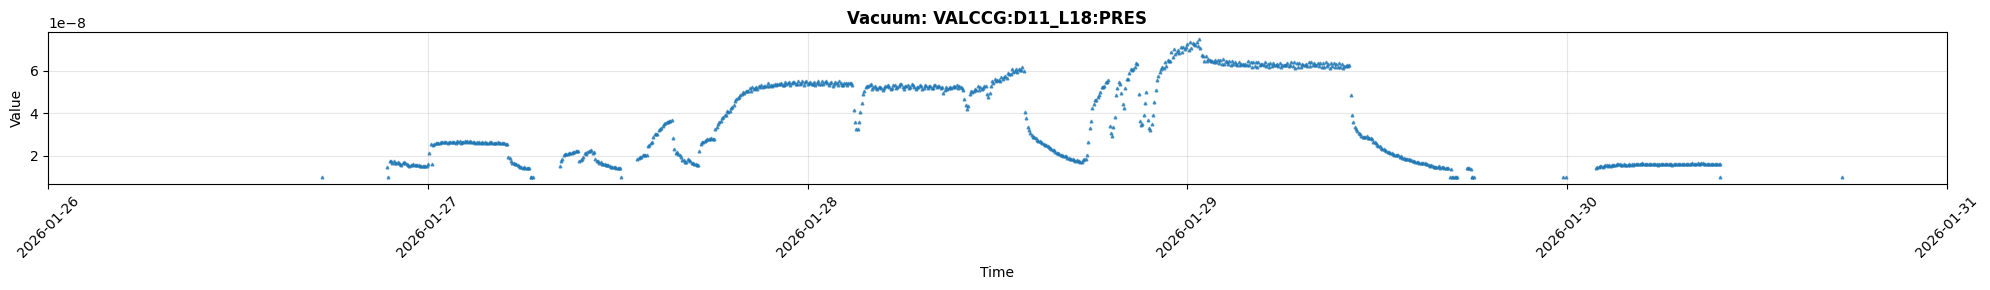

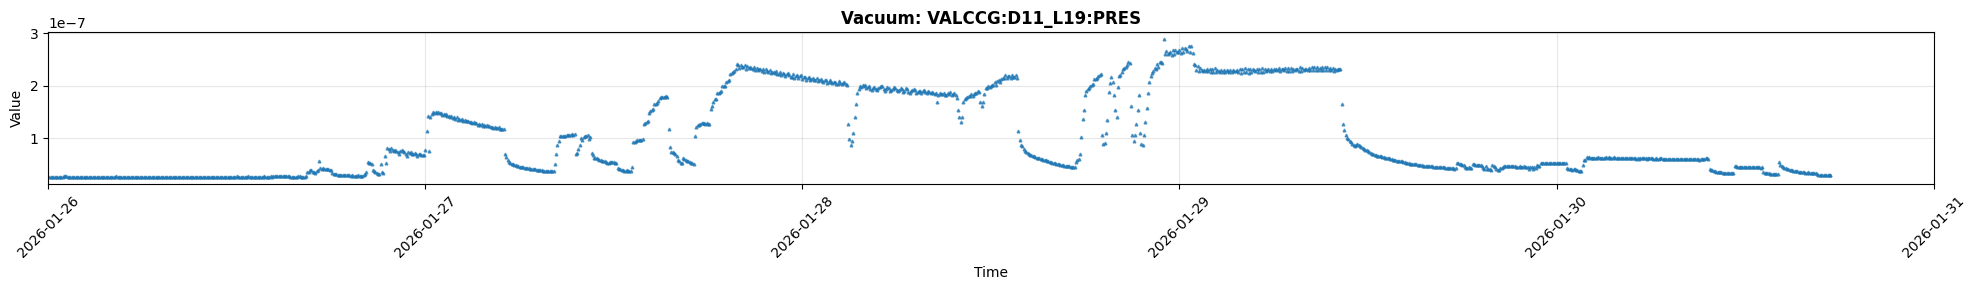

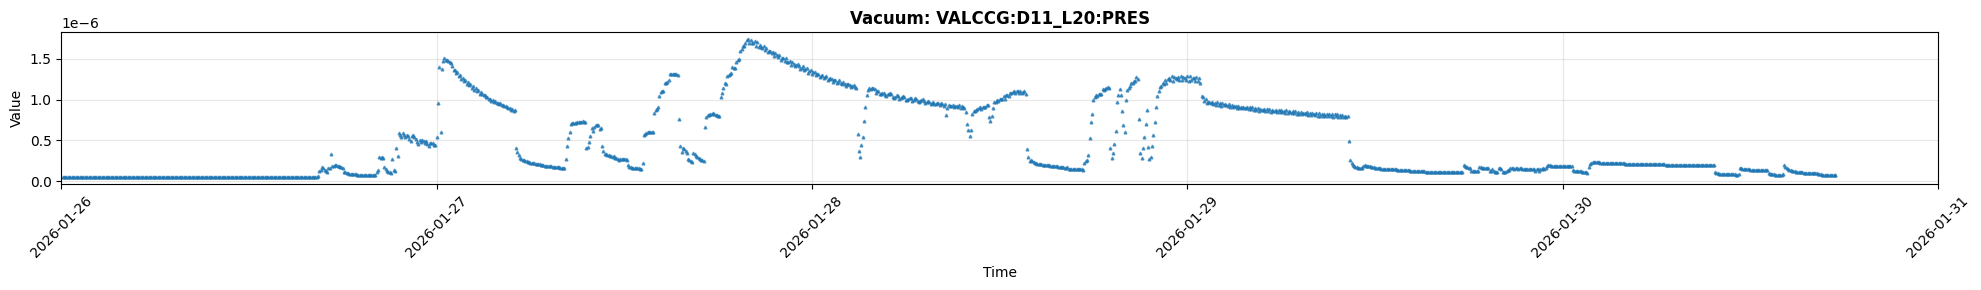

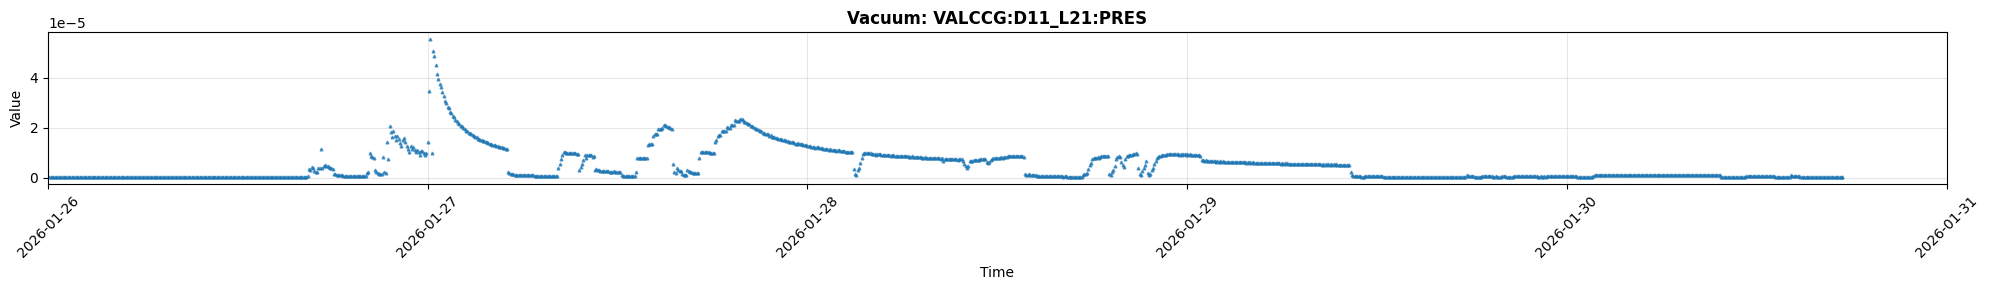

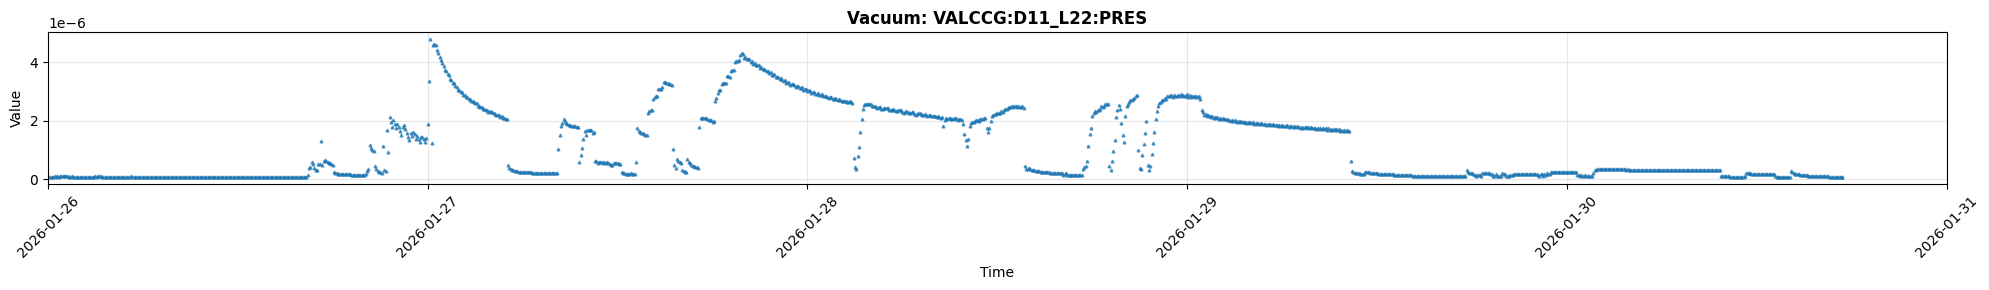

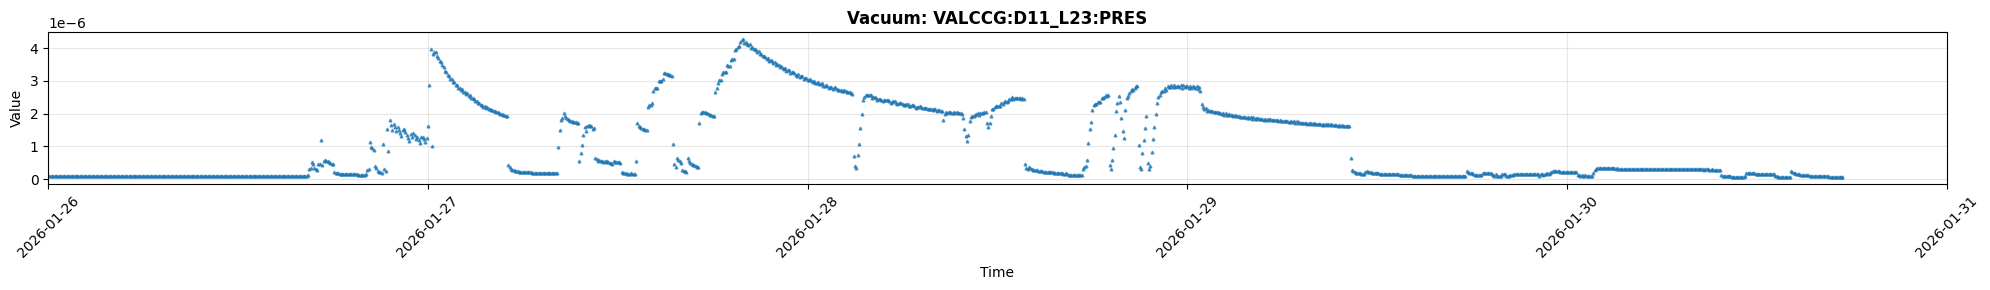

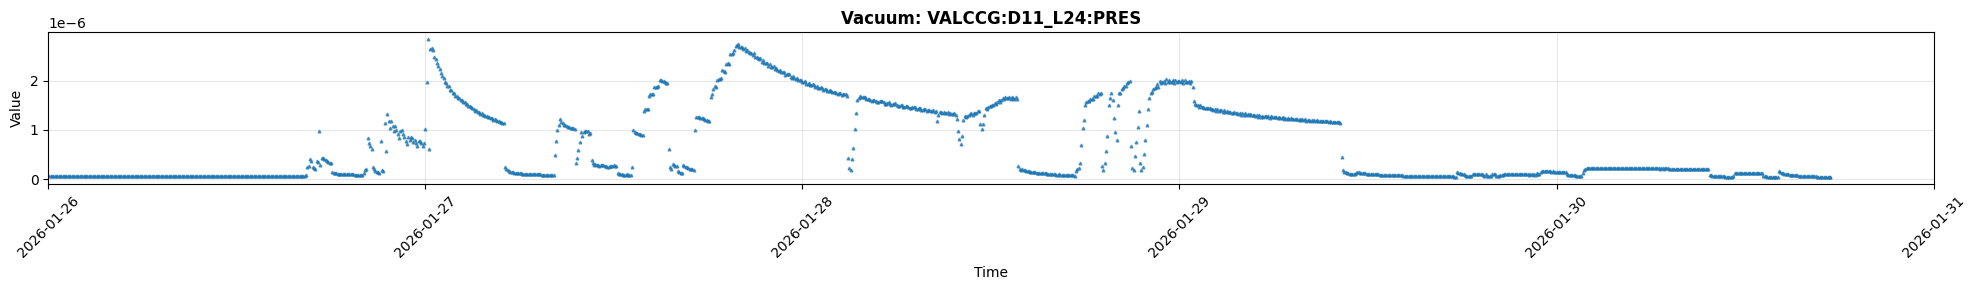


Created 59 individual plots:
  - ACC file 1: 19 plots
  - ACC file 2: 8 plots
  - Belle2: 9 plots
  - Vacuum: 23 plots


In [ ]:
# Individual plots - One plot per column, wide and short
import matplotlib.dates as mdates

print("Creating individual plots for each column...")

# Plot ACC file 1 data
for col in acc1_numeric_cols:
    fig, ax = plt.subplots(figsize=(20, 2))
    ax.plot(acc_df1['Timestamp'], acc_df1[col], marker='o', markersize=2, alpha=0.7, linestyle='-', label=f'ACC1: {col}')
    ax.set_ylabel('Value', fontsize=9)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE) + pd.Timedelta(days=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.xticks(rotation=45, fontsize=8)
    plt.tight_layout(pad=0.5)
    plt.show()

# Plot ACC file 2 data
for col in acc2_numeric_cols:
    fig, ax = plt.subplots(figsize=(20, 2))
    ax.plot(acc_df2['Timestamp'], acc_df2[col], marker='v', markersize=2, alpha=0.7, linestyle='-', label=f'ACC2: {col}')
    ax.set_ylabel('Value', fontsize=9)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE) + pd.Timedelta(days=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.xticks(rotation=45, fontsize=8)
    plt.tight_layout(pad=0.5)
    plt.show()

# Plot Belle2 data
for col in belle2_numeric_cols:
    fig, ax = plt.subplots(figsize=(20, 2))
    ax.plot(belle2_df['Timestamp'], belle2_df[col], marker='s', markersize=2, alpha=0.7, linestyle='-', label=f'Belle2: {col}')
    ax.set_ylabel('Value', fontsize=9)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE) + pd.Timedelta(days=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.xticks(rotation=45, fontsize=8)
    plt.tight_layout(pad=0.5)
    plt.show()

# Plot Vacuum data
for col in vacuum_numeric_cols:
    fig, ax = plt.subplots(figsize=(20, 2))
    ax.plot(vacuum_df['Timestamp'], vacuum_df[col], marker='^', markersize=2, alpha=0.7, linestyle='-', label=f'Vacuum: {col}')
    ax.set_ylabel('Value', fontsize=9)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE) + pd.Timedelta(days=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.xticks(rotation=45, fontsize=8)
    plt.tight_layout(pad=0.5)
    plt.show()

total_cols = len(acc1_numeric_cols) + len(acc2_numeric_cols) + len(belle2_numeric_cols) + len(vacuum_numeric_cols)
print(f"\nCreated {total_cols} individual plots:")
print(f"  - ACC file 1: {len(acc1_numeric_cols)} plots")
print(f"  - ACC file 2: {len(acc2_numeric_cols)} plots")
print(f"  - Belle2: {len(belle2_numeric_cols)} plots")
print(f"  - Vacuum: {len(vacuum_numeric_cols)} plots")